In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append(r"D:\git\MIPT\tools")

import plot_tools

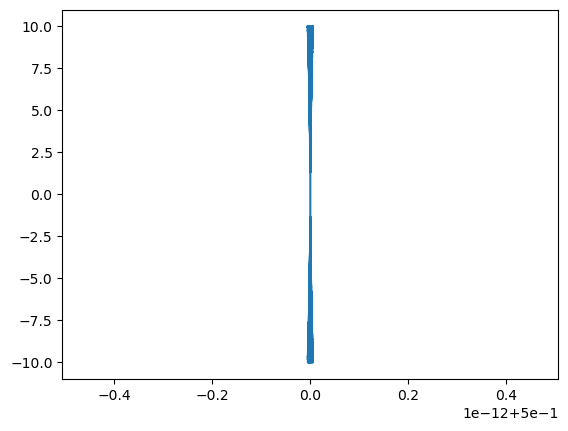

In [3]:
phi = np.linspace(0.1, 2*np.pi-0.1, 1000000)

z = 1 / (1 - np.exp(1j*phi))

plt.plot(z.real, z.imag)

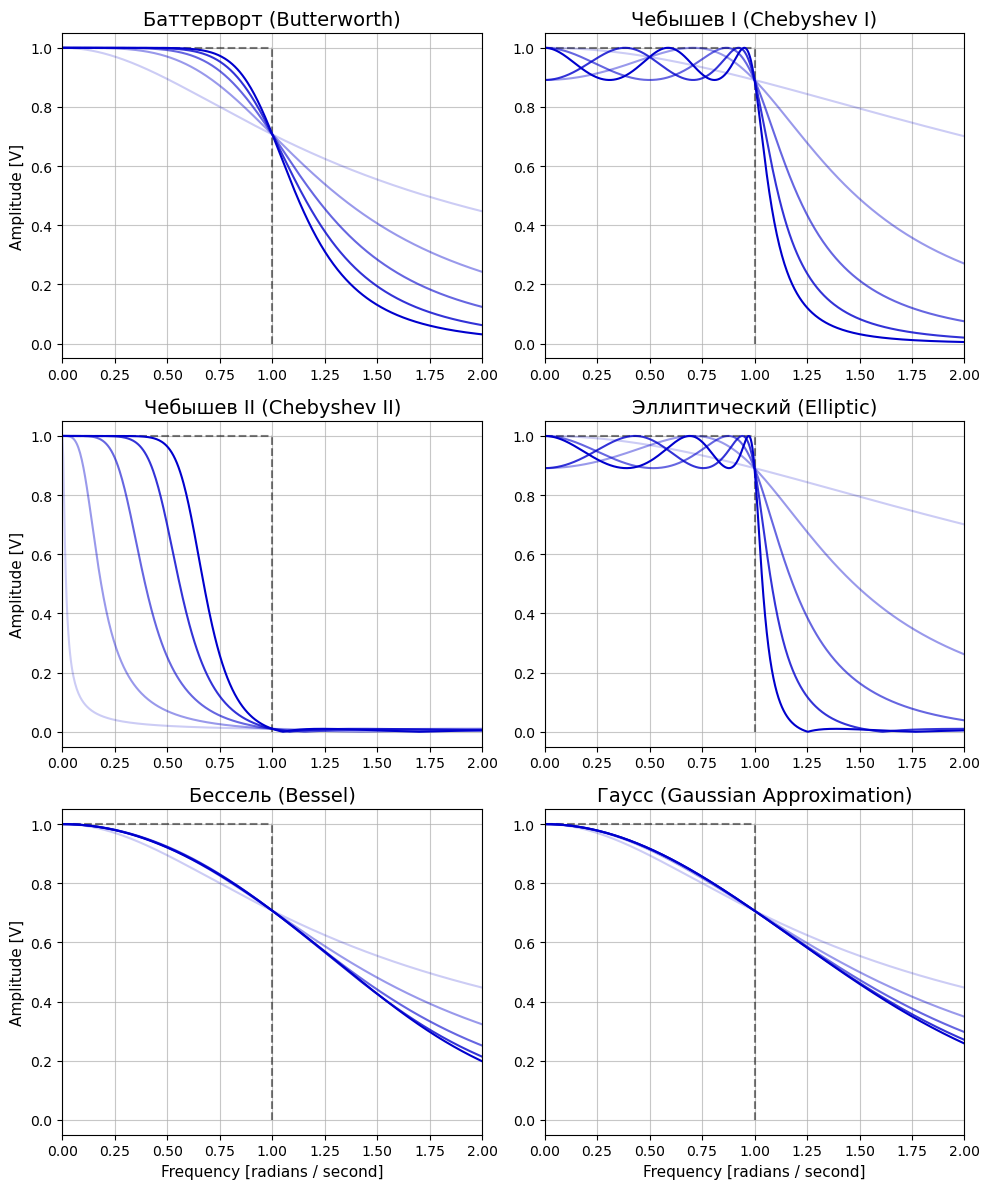

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка шрифтов и графиков
plt.style.use('default')
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Названия фильтров для графиков
filters = ['Баттерворт (Butterworth)', 'Чебышев I (Chebyshev I)', 
           'Чебышев II (Chebyshev II)', 'Эллиптический (Elliptic)', 
           'Бессель (Bessel)', 'Гаусс (Gaussian Approximation)']

# Порядки фильтров для построения
orders = [1, 2, 3, 4, 5]

# Массив частот (от 0 до 2 рад/с)
w = np.linspace(0, 2, 500)

def gaussian_mag(w, N):
    """
    В scipy.signal нет встроенного генератора ИИХ/аналоговых фильтров Гаусса.
    Поэтому мы используем стандартную математическую аппроксимацию АЧХ 
    на основе усеченного ряда Тейлора для функции e^(x^2).
    """
    # Находим масштабный коэффициент 'a', чтобы на частоте среза (w=1) затухание было строго -3 дБ (1/sqrt(2))
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    # Вычисляем амплитуду
    mag_sq = np.zeros_like(w)
    for k in range(N+1):
        mag_sq += (a * w**2)**k / math.factorial(k)
    return 1.0 / np.sqrt(mag_sq)

for i, title in enumerate(filters):
    ax = axes[i]
    ax.set_title(title, fontsize=14)
    
    # Отрисовка идеального фильтра (пунктирные линии, как на исходной картинке)
    ax.plot([0, 1], [1, 1], 'k--', alpha=0.5)
    ax.plot([1, 1], [0, 1], 'k--', alpha=0.5)
    
    for idx, N in enumerate(orders):
        # Расчет прозрачности: первый порядок бледный (0.2), последний - полностью непрозрачный (1.0)
        alpha_val = 0.2 + 0.8 * (idx / (len(orders) - 1))
        
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 1:
            # Неравномерность в полосе пропускания 1 дБ
            b, a = signal.cheby1(N, 1, 1, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 2:
            # Затухание в полосе подавления 40 дБ
            b, a = signal.cheby2(N, 40, 1, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 3:
            # Неравномерность 1 дБ, затухание 40 дБ
            b, a = signal.ellip(N, 1, 40, 1, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 4:
            # norm='mag' сдвигает частоту среза на уровень -3 дБ для корректного визуального сравнения
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 5:
            # Аппроксимация фильтра Гаусса
            mag = gaussian_mag(w, N)
            
        ax.plot(w, mag, color='mediumblue', alpha=alpha_val)

    # Оформление осей
    ax.grid(True, linestyle='-', alpha=0.7)
    ax.set_xlim(0, 2)
    ax.set_ylim(-0.05, 1.05)
    
    # Добавляем подписи осей только с краев матрицы для чистоты
    if i >= 4:
        ax.set_xlabel('Frequency [radians / second]', fontsize=11)
    if i % 2 == 0:
        ax.set_ylabel('Amplitude [V]', fontsize=11)

plt.tight_layout()
plt.show()

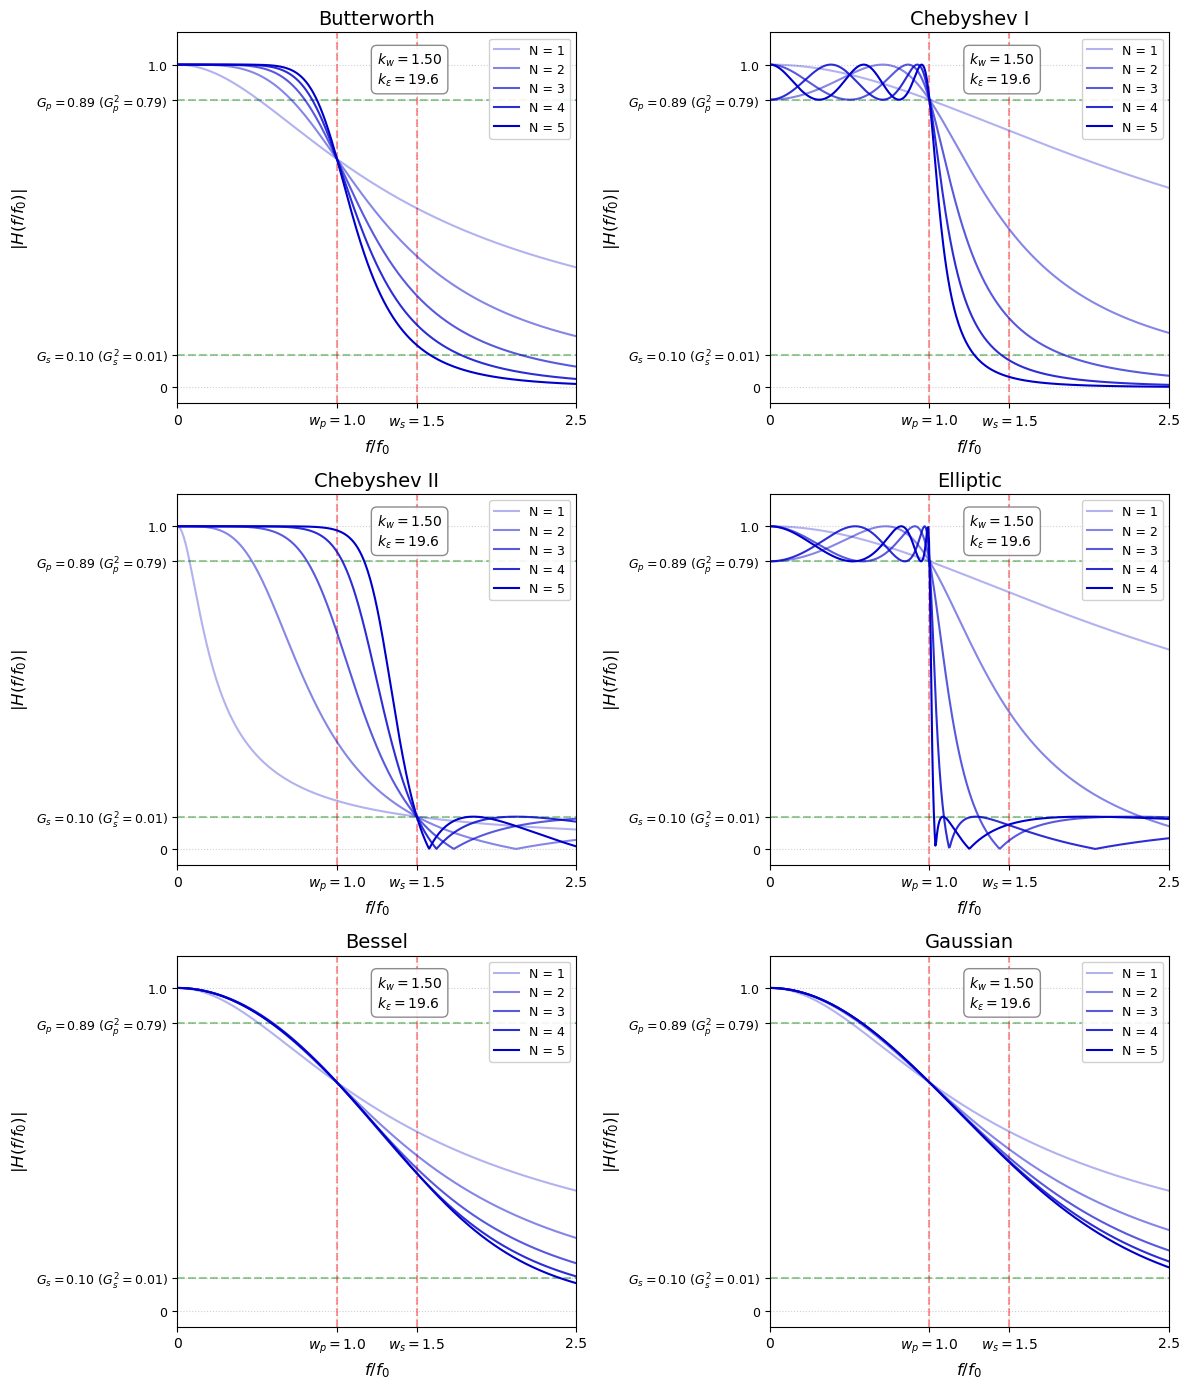

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка шрифтов и графиков
plt.style.use('default')
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

# 3. Убраны названия на русском
filters = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptic', 'Bessel', 'Gaussian']

# 5. Использование np.linspace для порядков (с приведением к int, так как порядок фильтра - целое число)
orders = np.linspace(1, 5, 5, dtype=int)

# Массив частот
w = np.linspace(0, 2.5, 500)

# --- Параметры коридора АЧХ ---
wp = 1.0   # Граница полосы пропускания
ws = 1.5   # Граница полосы подавления
Rp = 1.0   # Неравномерность в полосе пропускания (дБ)
Rs = 20.0  # Минимальное затухание в полосе подавления (дБ)

# Пересчет дБ в разы (Амплитуда G и Мощность G^2)
Gp = 10 ** (-Rp / 20)
Gs = 10 ** (-Rs / 20)
Gp2 = 10 ** (-Rp / 10)
Gs2 = 10 ** (-Rs / 10)

# Вычисление коэффициентов прямоугольности и k_epsilon
kw = ws / wp
k_eps = np.sqrt(10**(Rs/10) - 1) / np.sqrt(10**(Rp/10) - 1)

def gaussian_mag(w, N):
    """Аппроксимация АЧХ фильтра Гаусса"""
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    mag_sq = np.zeros_like(w)
    for k in range(N+1):
        mag_sq += (a * w**2)**k / math.factorial(k)
    return 1.0 / np.sqrt(mag_sq)

for i, title in enumerate(filters):
    ax = axes[i]
    ax.set_title(title, fontsize=14)
    
    # 1. Характерные вертикальные и горизонтальные линии коридора
    ax.axvline(wp, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    ax.axvline(ws, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    ax.axhline(Gp, color='green', linestyle='--', alpha=0.4, linewidth=1.5)
    ax.axhline(Gs, color='green', linestyle='--', alpha=0.4, linewidth=1.5)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.3 + 0.7 * (idx / (len(orders) - 1))
        
        if i == 0:
            b, a = signal.butter(N, wp, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 1:
            b, a = signal.cheby1(N, Rp, wp, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 2:
            # Для Чебышева II частота среза определяет начало полосы подавления (ws)
            b, a = signal.cheby2(N, Rs, ws, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 3:
            b, a = signal.ellip(N, Rp, Rs, wp, analog=True)
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 4:
            b, a = signal.bessel(N, wp, analog=True, norm='mag')
            _, h = signal.freqs(b, a, w)
            mag = np.abs(h)
        elif i == 5:
            mag = gaussian_mag(w, N)
            
        # 2. Добавление label для легенды
        ax.plot(w, mag, color='mediumblue', alpha=alpha_val, label=f'N = {N}')

    # Оформление осей и сетки
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-0.05, 1.1)
    
    # 4. Подписи осей f/f0 и |H(f/f0)|
    ax.set_xlabel('$f / f_0$', fontsize=12)
    ax.set_ylabel('$|H(f / f_0)|$', fontsize=12)
    
    # 1. Подписание значений на осях вместе с буквенными обозначениями (wp, ws, Gp^2, Gs^2)
    ax.set_xticks([0, wp, ws, 2.5])
    ax.set_xticklabels(['0', f'$w_p={wp}$', f'$w_s={ws}$', '2.5'], fontsize=10)
    
    ax.set_yticks([0, Gs, Gp, 1])
    ax.set_yticklabels([
        '0', 
        f'$G_s={Gs:.2f}$ $(G_s^2={Gs2:.2f})$', 
        f'$G_p={Gp:.2f}$ $(G_p^2={Gp2:.2f})$', 
        '1.0'
    ], fontsize=9)
    
    # 1. Вывод kw и k_epsilon текстом на графике
    props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.50, 0.95, f'$k_w = {kw:.2f}$\n$k_\\epsilon = {k_eps:.1f}$', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # 2. Отображение легенды (порядок кривых)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    ax.grid(True)

plt.tight_layout()
plt.show()


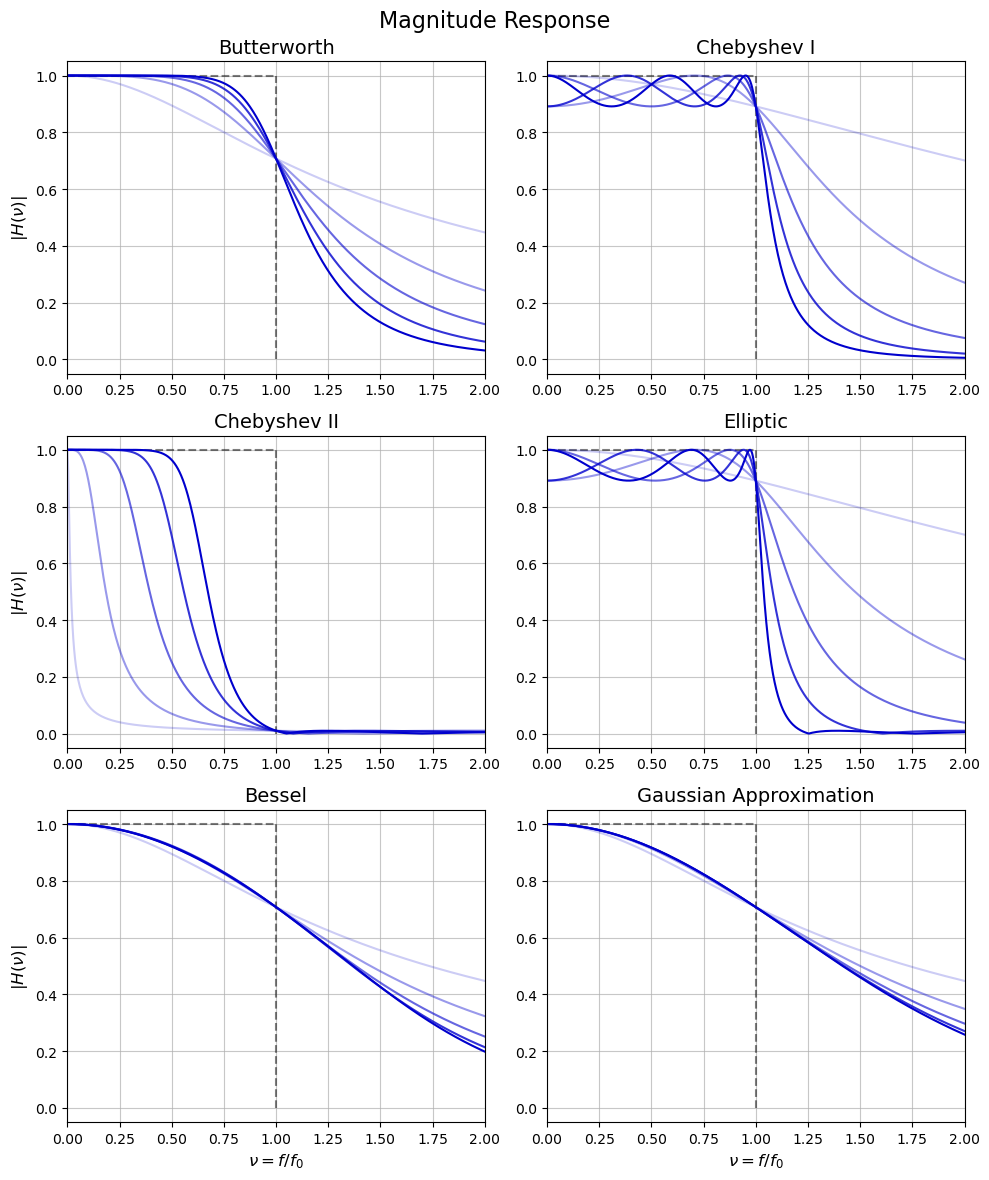

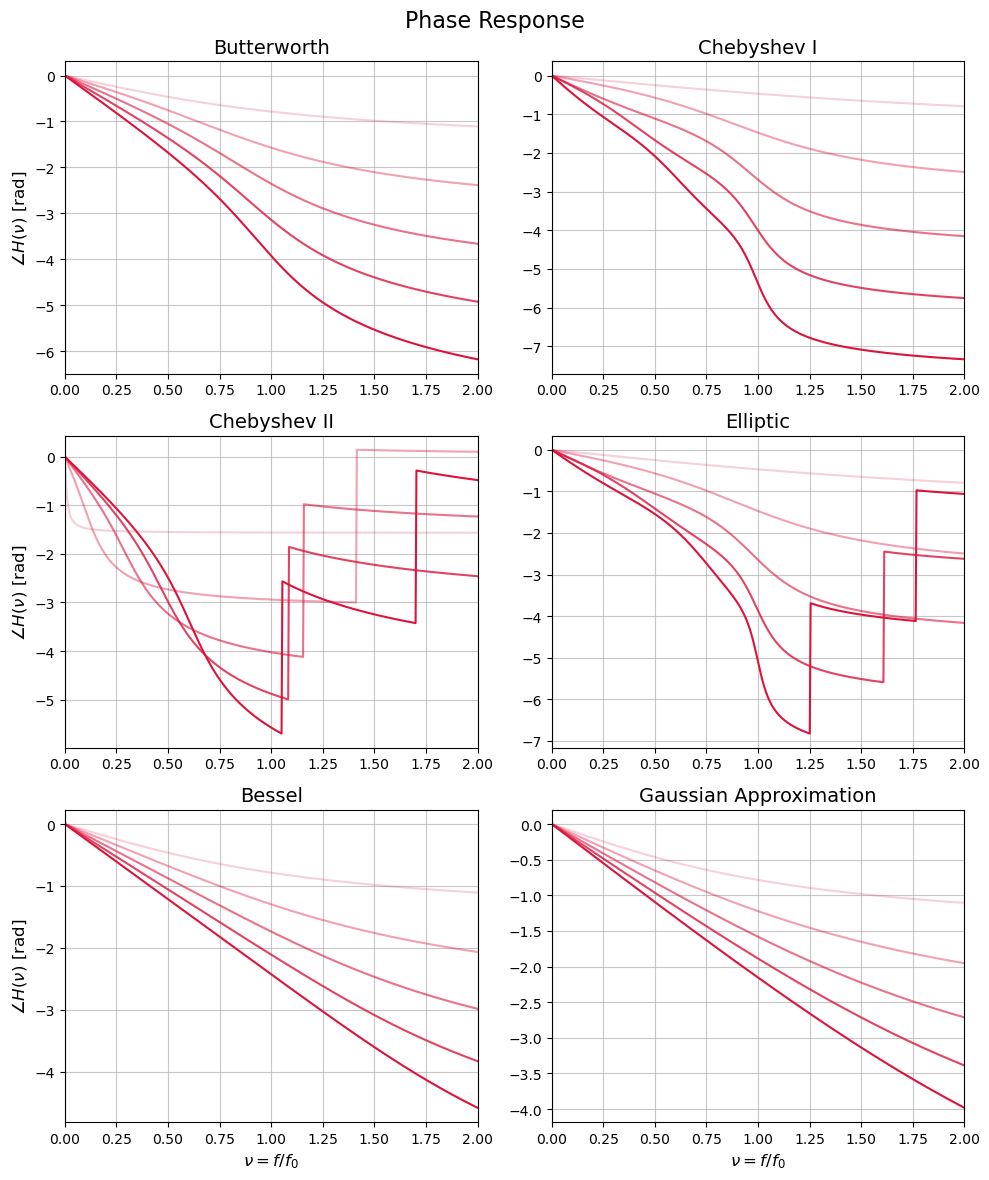

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка шрифтов и стилей
plt.style.use('default')

# Названия фильтров (только на английском)
filters = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 
           'Elliptic', 'Bessel', 'Gaussian Approximation']

# Порядки фильтров
orders = [1, 2, 3, 4, 5]

# Массив частот (от 0 до 2)
w = np.linspace(0, 2, 500)

def get_gaussian_analog_filter(N):
    """
    Создает аналоговый фильтр Гаусса (коэффициенты числителя и знаменателя)
    на основе аппроксимации ряда Тейлора.
    """
    # Находим масштабный коэффициент 'a', чтобы затухание на w=1 было -3 дБ
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    # Строим полином знаменателя. Решаем относительно s^2, затем находим s.
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse() # Старшая степень первой
    x_roots = np.roots(coeffs)
    
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        # Оставляем только полюса в левой полуплоскости (для устойчивости)
        if s1.real < 0:
            s_roots.append(s1)
        elif s2.real < 0:
            s_roots.append(s2)
            
    den = np.poly(s_roots)
    num = [den[-1].real] # Коэффициент для единичного усиления на нулевой частоте
    return num, den.real

# ==========================================
# Построение АЧХ (Magnitude Response)
# ==========================================
fig_mag, axes_mag = plt.subplots(3, 2, figsize=(10, 12))
axes_mag = axes_mag.flatten()
fig_mag.suptitle('Magnitude Response', fontsize=16, y=0.98)

# ==========================================
# Построение ФЧХ (Phase Response)
# ==========================================
fig_phase, axes_phase = plt.subplots(3, 2, figsize=(10, 12))
axes_phase = axes_phase.flatten()
fig_phase.suptitle('Phase Response', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax_m = axes_mag[i]
    ax_p = axes_phase[i]
    
    ax_m.set_title(title, fontsize=14)
    ax_p.set_title(title, fontsize=14)
    
    # Опорные линии для АЧХ
    ax_m.plot([0, 1], [1, 1], 'k--', alpha=0.5)
    ax_m.plot([1, 1], [0, 1], 'k--', alpha=0.5)
    
    for idx, N in enumerate(orders):
        # Расчет прозрачности
        alpha_val = 0.2 + 0.8 * (idx / (len(orders) - 1))
        
        # Получение коэффициентов фильтра
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
        elif i == 1:
            b, a = signal.cheby1(N, 1, 1, analog=True)
        elif i == 2:
            b, a = signal.cheby2(N, 40, 1, analog=True)
        elif i == 3:
            b, a = signal.ellip(N, 1, 40, 1, analog=True)
        elif i == 4:
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5:
            b, a = get_gaussian_analog_filter(N)
            
        # Вычисление частотного отклика
        _, h = signal.freqs(b, a, w)
        
        # АЧХ
        mag = np.abs(h)
        ax_m.plot(w, mag, color='mediumblue', alpha=alpha_val)
        
        # ФЧХ (развернутая фаза для непрерывности графика)
        phase = np.unwrap(np.angle(h))
        ax_p.plot(w, phase, color='crimson', alpha=alpha_val)

    # Оформление осей АЧХ
    ax_m.grid(True, linestyle='-', alpha=0.7)
    ax_m.set_xlim(0, 2)
    ax_m.set_ylim(-0.05, 1.05)
    
    if i >= 4:
        ax_m.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
    if i % 2 == 0:
        ax_m.set_ylabel(r'$|H(\nu)|$', fontsize=12)

    # Оформление осей ФЧХ
    ax_p.grid(True, linestyle='-', alpha=0.7)
    ax_p.set_xlim(0, 2)
    
    if i >= 4:
        ax_p.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
    if i % 2 == 0:
        ax_p.set_ylabel(r'$\angle H(\nu)$ [rad]', fontsize=12)

fig_mag.tight_layout()
fig_phase.tight_layout()

plt.show()

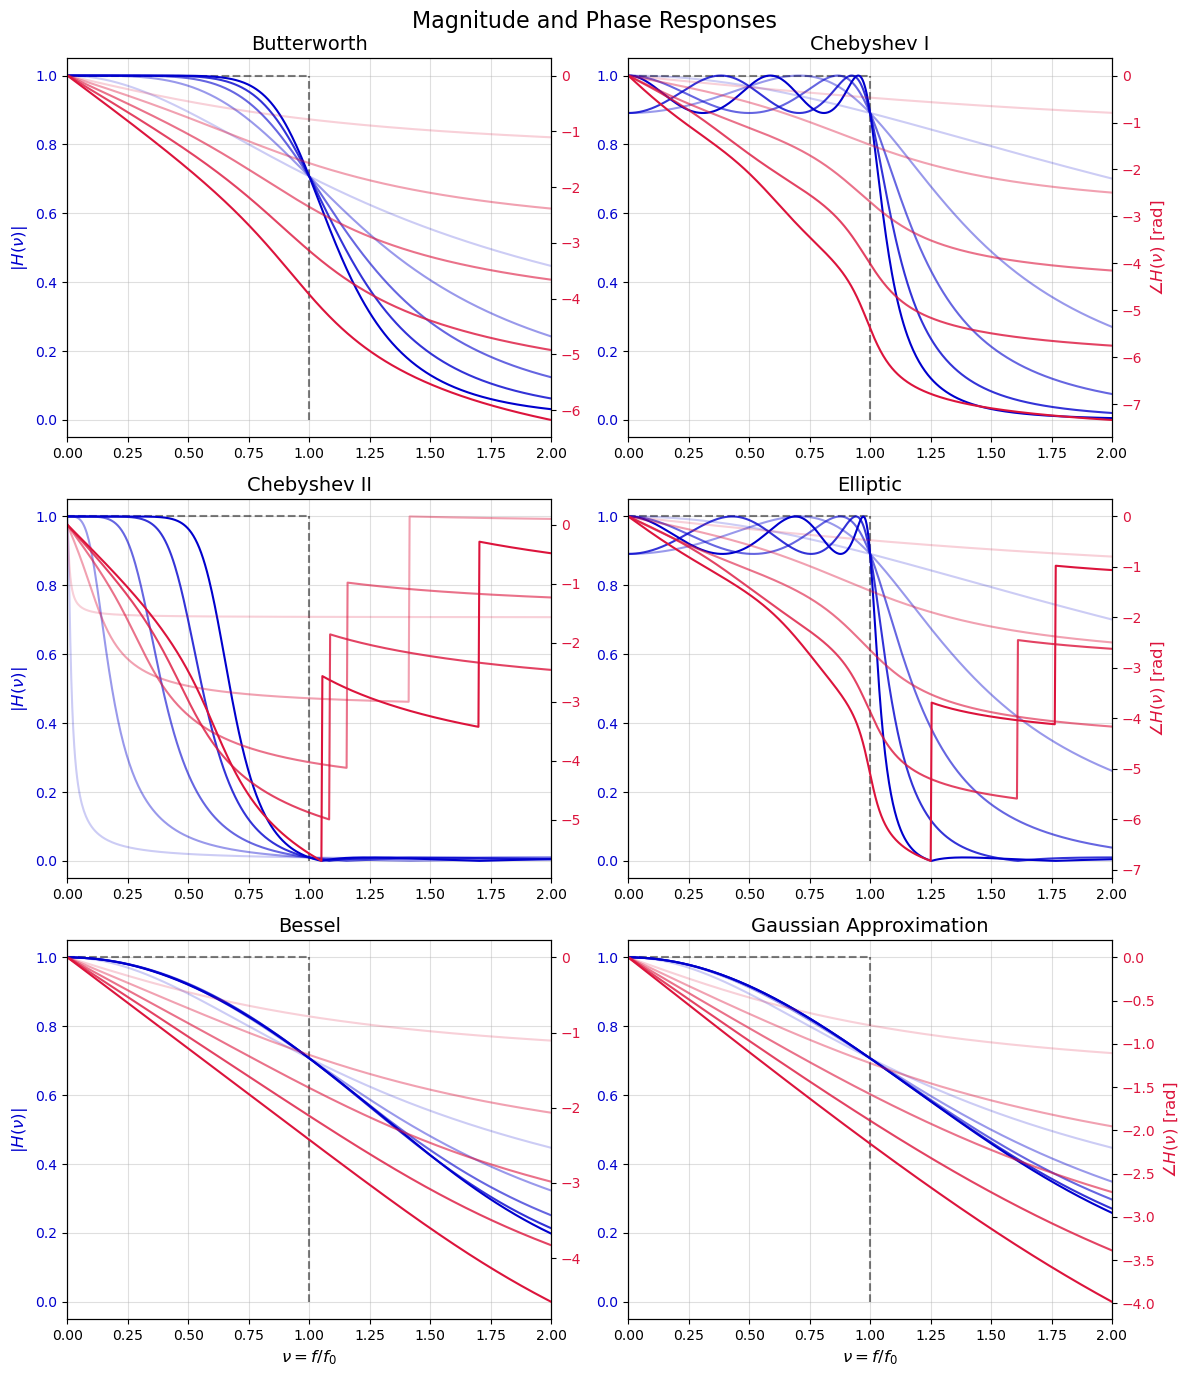

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Названия фильтров (на английском)
filters = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 
           'Elliptic', 'Bessel', 'Gaussian Approximation']

# Порядки фильтров
orders = [1, 2, 3, 4, 5]

# Массив частот
w = np.linspace(0, 2, 500)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0:
            s_roots.append(s1)
        elif s2.real < 0:
            s_roots.append(s2)
            
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

fig, axes = plt.subplots(3, 2, figsize=(12, 14)) # Немного увеличим ширину для двух осей
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax1 = axes[i]             # Левая ось (АЧХ)
    ax2 = ax1.twinx()         # Правая ось (ФЧХ)
    
    ax1.set_title(title, fontsize=14)
    
    # Опорные линии для АЧХ
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1], [0, 1], color='black', linestyle='--', alpha=0.5)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.2 + 0.8 * (idx / (len(orders) - 1))
        
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
        elif i == 1:
            b, a = signal.cheby1(N, 1, 1, analog=True)
        elif i == 2:
            b, a = signal.cheby2(N, 40, 1, analog=True)
        elif i == 3:
            b, a = signal.ellip(N, 1, 40, 1, analog=True)
        elif i == 4:
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5:
            b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        # Отрисовка кривых
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    # Подписи осей X (только для нижнего ряда)
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    # Подписи осей Y (АЧХ слева, ФЧХ справа)
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

fig.tight_layout()
plt.show()


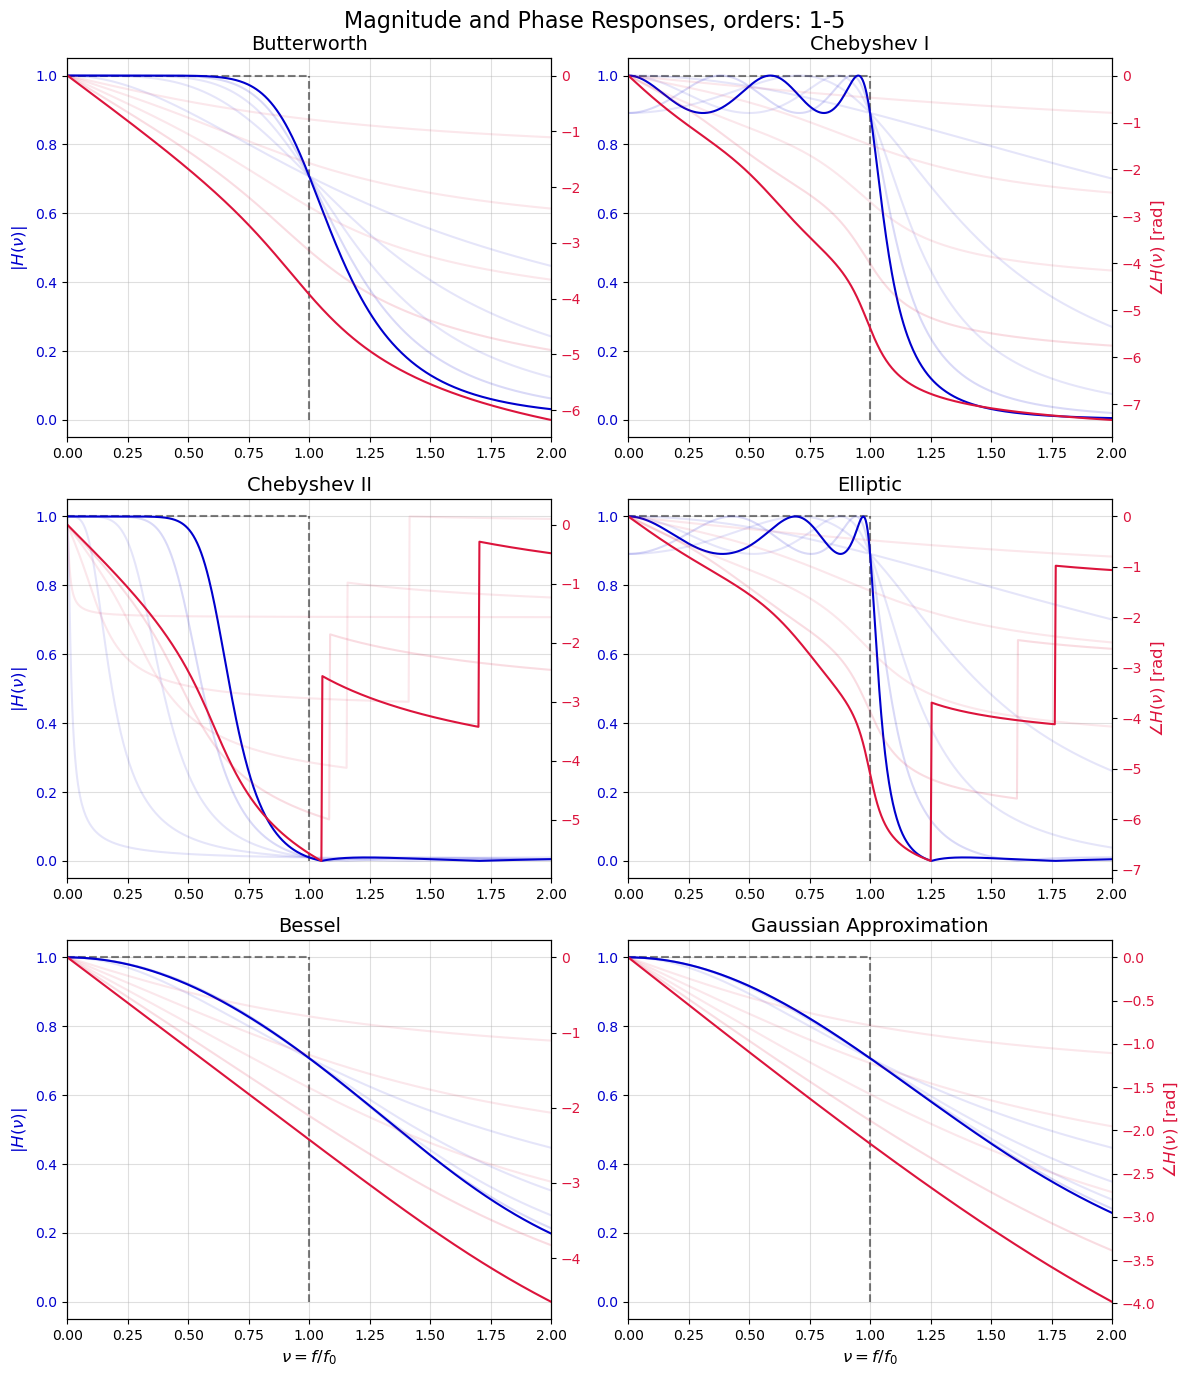

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Названия фильтров (на английском)
filters = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 
           'Elliptic', 'Bessel', 'Gaussian Approximation']

# Порядки фильтров
orders = [1, 2, 3, 4, 5]

# Массив частот
w = np.linspace(0, 2, 500)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0:
            s_roots.append(s1)
        elif s2.real < 0:
            s_roots.append(s2)
            
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses, orders: 1-5', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax1 = axes[i]             # Левая ось (АЧХ)
    ax2 = ax1.twinx()         # Правая ось (ФЧХ)
    
    ax1.set_title(title, fontsize=14)
    
    # Опорные линии для АЧХ
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1], [0, 1], color='black', linestyle='--', alpha=0.5)
    
    for idx, N in enumerate(orders):
        # Нелинейная шкала прозрачности:
        # idx = 0 -> alpha = 0.1 (очень прозрачно, но заметно)
        # idx = 4 -> alpha = 1.0 (полностью непрозрачно)
        # Промежуточные: ~0.15, ~0.32, ~0.6
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
        elif i == 1:
            b, a = signal.cheby1(N, 1, 1, analog=True)
        elif i == 2:
            b, a = signal.cheby2(N, 40, 1, analog=True)
        elif i == 3:
            b, a = signal.ellip(N, 1, 40, 1, analog=True)
        elif i == 4:
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5:
            b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        # Отрисовка кривых с новым значением alpha
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    # Подписи осей X (только для нижнего ряда)
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    # Подписи осей Y (АЧХ слева, ФЧХ справа)
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

fig.tight_layout()
plt.show()

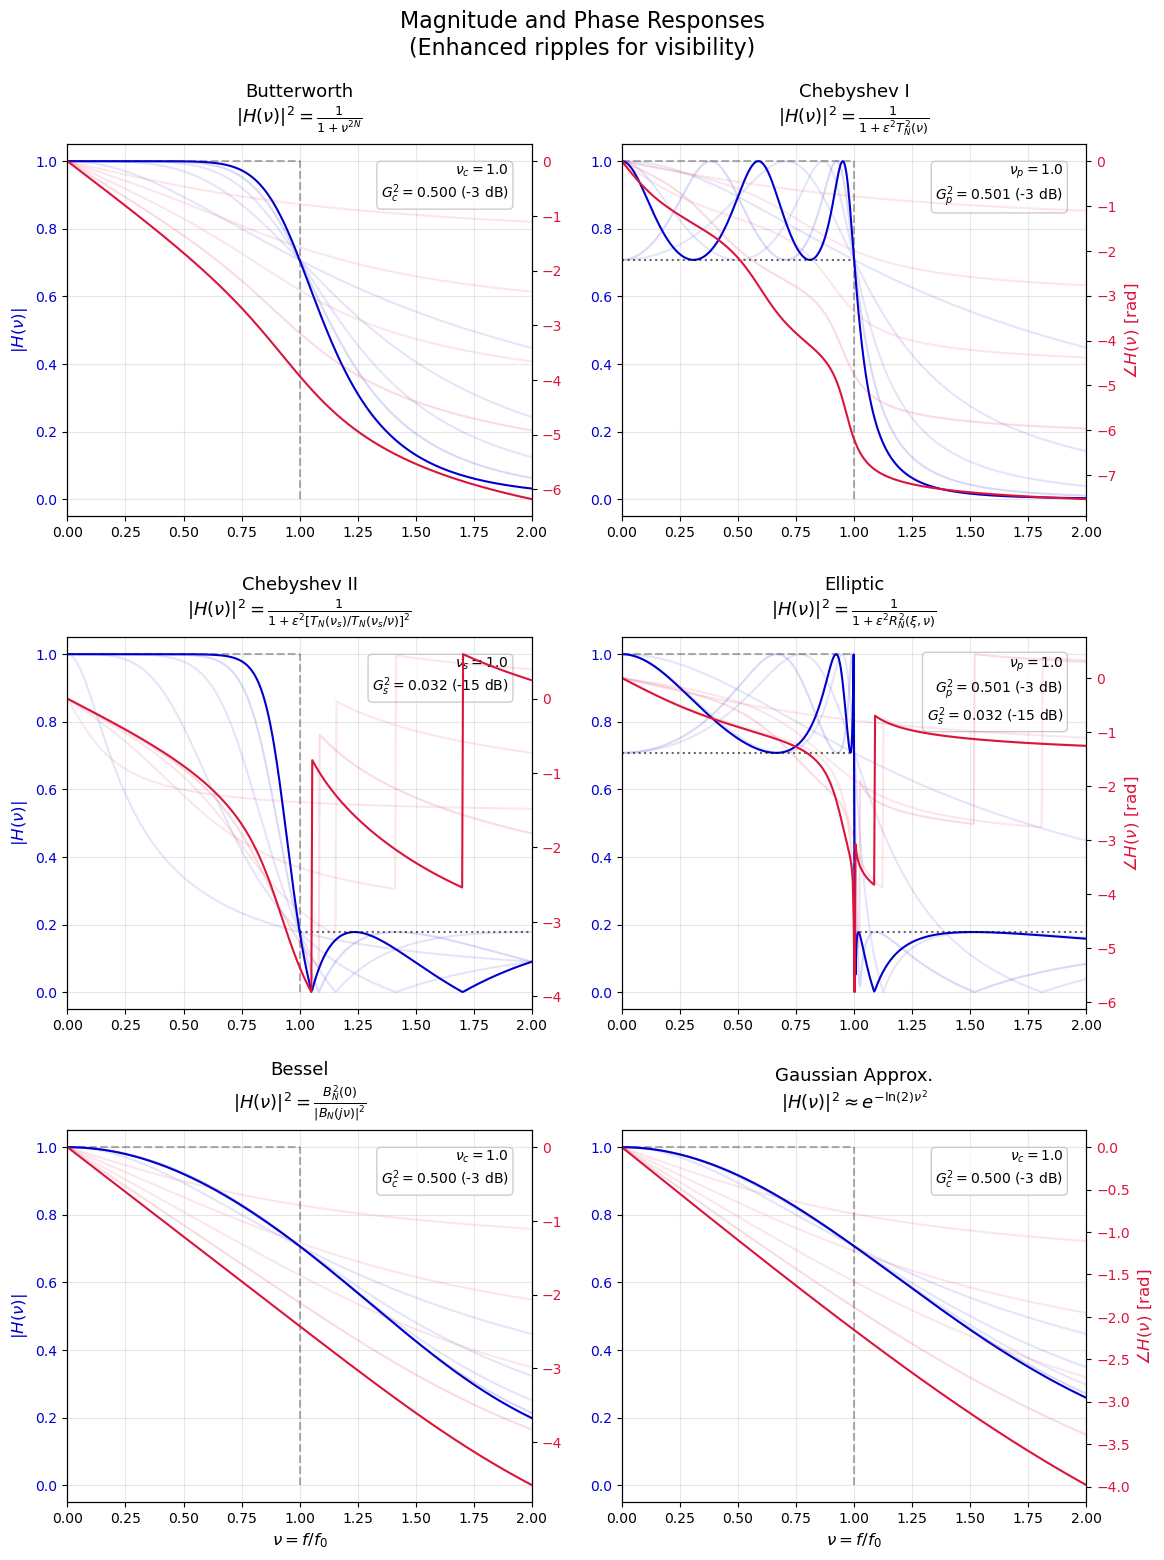

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Параметры пульсаций для лучшей визуализации
rp = 3   # Неравномерность в полосе пропускания (3 дБ)
rs = 15  # Затухание в полосе подавления (15 дБ)

# Расчет амплитудных и энергетических уровней
Gp_amp = 10**(-rp/20) # Амплитуда ~0.707
Gs_amp = 10**(-rs/20) # Амплитуда ~0.177
Gp_sq = 10**(-rp/10)  # Мощность ~0.501
Gs_sq = 10**(-rs/10)  # Мощность ~0.0316

# Названия фильтров с формулами квадрата АЧХ |H(nu)|^2
filters = [
    'Butterworth\n' + r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$',
    'Chebyshev I\n' + r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 T_N^2(\nu)}$',
    'Chebyshev II\n' + r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 \left[T_N(\nu_s)/T_N(\nu_s/\nu)\right]^2}$',
    'Elliptic\n' + r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 R_N^2(\xi, \nu)}$',
    'Bessel\n' + r'$|H(\nu)|^2 = \frac{B_N^2(0)}{|B_N(j\nu)|^2}$',
    'Gaussian Approx.\n' + r'$|H(\nu)|^2 \approx e^{-\ln(2)\nu^2}$'
]

orders = [1, 2, 3, 4, 5]
w = np.linspace(0, 2, 500)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0:
            s_roots.append(s1)
        elif s2.real < 0:
            s_roots.append(s2)
            
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

color_mag = 'mediumblue'
color_phase = 'crimson'

# Увеличим высоту графика, чтобы вместить формулы
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses\n(Enhanced ripples for visibility)', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax1 = axes[i]             
    ax2 = ax1.twinx()         
    
    ax1.set_title(title, fontsize=13, pad=15)
    
    # Опорные вертикальные/горизонтальные линии (идеальный фильтр)
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.3)
    ax1.plot([1, 1], [0, 1], color='black', linestyle='--', alpha=0.3)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
        elif i == 1:
            b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2:
            b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i == 3:
            b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i == 4:
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5:
            b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # Добавление информационных блоков с параметрами и уровней пульсаций
    textstr = ""
    if i == 1: # Chebyshev I
        textstr = f"$\\nu_p = 1.0$\n$G_p^2 = {Gp_sq:.3f}$ (-{rp} dB)"
        ax1.plot([0, 1], [Gp_amp, Gp_amp], 'k:', alpha=0.6) # Линия границы пульсаций
    elif i == 2: # Chebyshev II
        textstr = f"$\\nu_s = 1.0$\n$G_s^2 = {Gs_sq:.3f}$ (-{rs} dB)"
        ax1.plot([1, 2], [Gs_amp, Gs_amp], 'k:', alpha=0.6) 
    elif i == 3: # Elliptic
        textstr = f"$\\nu_p = 1.0$\n$G_p^2 = {Gp_sq:.3f}$ (-{rp} dB)\n$G_s^2 = {Gs_sq:.3f}$ (-{rs} dB)"
        ax1.plot([0, 1], [Gp_amp, Gp_amp], 'k:', alpha=0.6)
        ax1.plot([1, 2], [Gs_amp, Gs_amp], 'k:', alpha=0.6)
    elif i in [0, 4, 5]: # Butterworth, Bessel, Gaussian
        textstr = "$\\nu_c = 1.0$\n$G_c^2 = 0.500$ (-3 dB)"

    # Отрисовка текстового блока в правом верхнем углу
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='silver')
    ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=props, zorder=5)

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.3)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    # Подписи
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

fig.tight_layout(pad=2.0) # Увеличенные отступы для формул
plt.show()

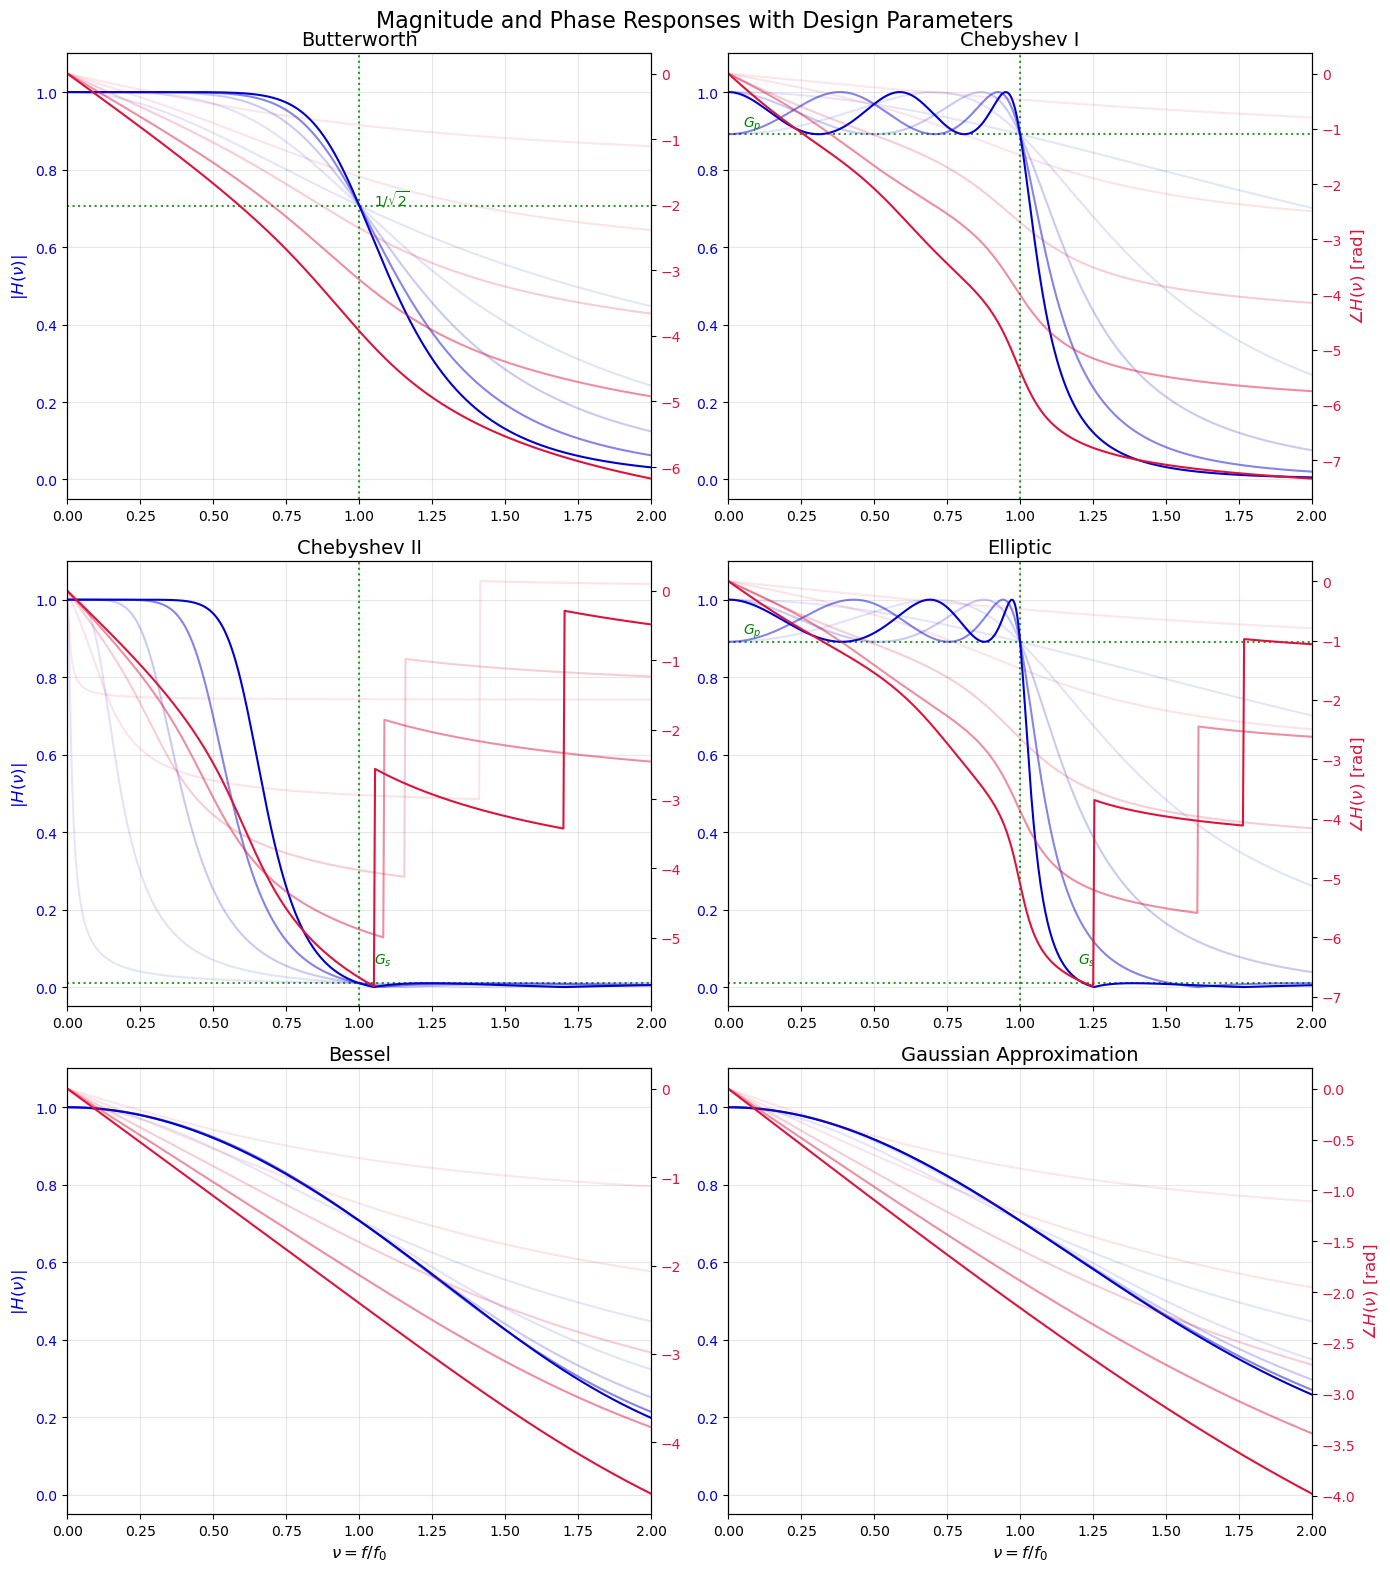

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Параметры фильтров, используемые в функциях signal.*
rp = 1    # Максимальные потери в полосе пропускания (dB)
rs = 40   # Минимальное затухание в полосе заграждения (dB)

# Расчет коэффициентов усиления (Gain) в линейном масштабе
gp = 10**(-rp/20)
gs = 10**(-rs/20)
butter_3db = 1/np.sqrt(2)

# Названия фильтров
filters = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 
           'Elliptic', 'Bessel', 'Gaussian Approximation']

orders = [1, 2, 3, 4, 5]
w = np.linspace(0, 2, 500)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j); s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses with Design Parameters', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax1.set_title(title, fontsize=14)
    
    # Специфические линии параметров для каждого типа
    line_style = {'color': 'green', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8}
    
    if title == 'Butterworth':
        # wp = 1, уровень 1/sqrt(2)
        ax1.axhline(butter_3db, **line_style)
        ax1.axvline(1, **line_style)
        ax1.text(1.05, butter_3db, r'$1/\sqrt{2}$', color='green')
        
    elif title == 'Chebyshev I':
        # wp = 1, уровень Gp
        ax1.axhline(gp, **line_style)
        ax1.axvline(1, **line_style)
        ax1.text(0.05, gp+0.02, r'$G_p$', color='green')
        
    elif title == 'Chebyshev II':
        # ws = 1, уровень Gs
        ax1.axhline(gs, **line_style)
        ax1.axvline(1, **line_style)
        ax1.text(1.05, gs+0.05, r'$G_s$', color='green')
        
    elif title == 'Elliptic':
        # wp = 1 (в scipy), уровень Gp и Gs
        ax1.axhline(gp, **line_style)
        ax1.axhline(gs, **line_style)
        ax1.axvline(1, **line_style)
        ax1.text(0.05, gp+0.02, r'$G_p$', color='green')
        ax1.text(1.2, gs+0.05, r'$G_s$', color='green')

    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**3 # Сделал чуть менее агрессивным
        
        if i == 0: b, a = signal.butter(N, 1, analog=True)
        elif i == 1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i == 3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i == 4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5: b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        ax1.plot(w, mag, color='mediumblue', alpha=alpha_val)
        ax2.plot(w, phase, color='crimson', alpha=alpha_val)

    ax1.grid(True, linestyle='-', alpha=0.3)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.1)
    ax1.tick_params(axis='y', labelcolor='mediumblue')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    if i >= 4: ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
    if i % 2 == 0: ax1.set_ylabel(r'$|H(\nu)|$', color='mediumblue', fontsize=12)
    if i % 2 == 1: ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color='crimson', fontsize=12)

fig.tight_layout()
plt.show()

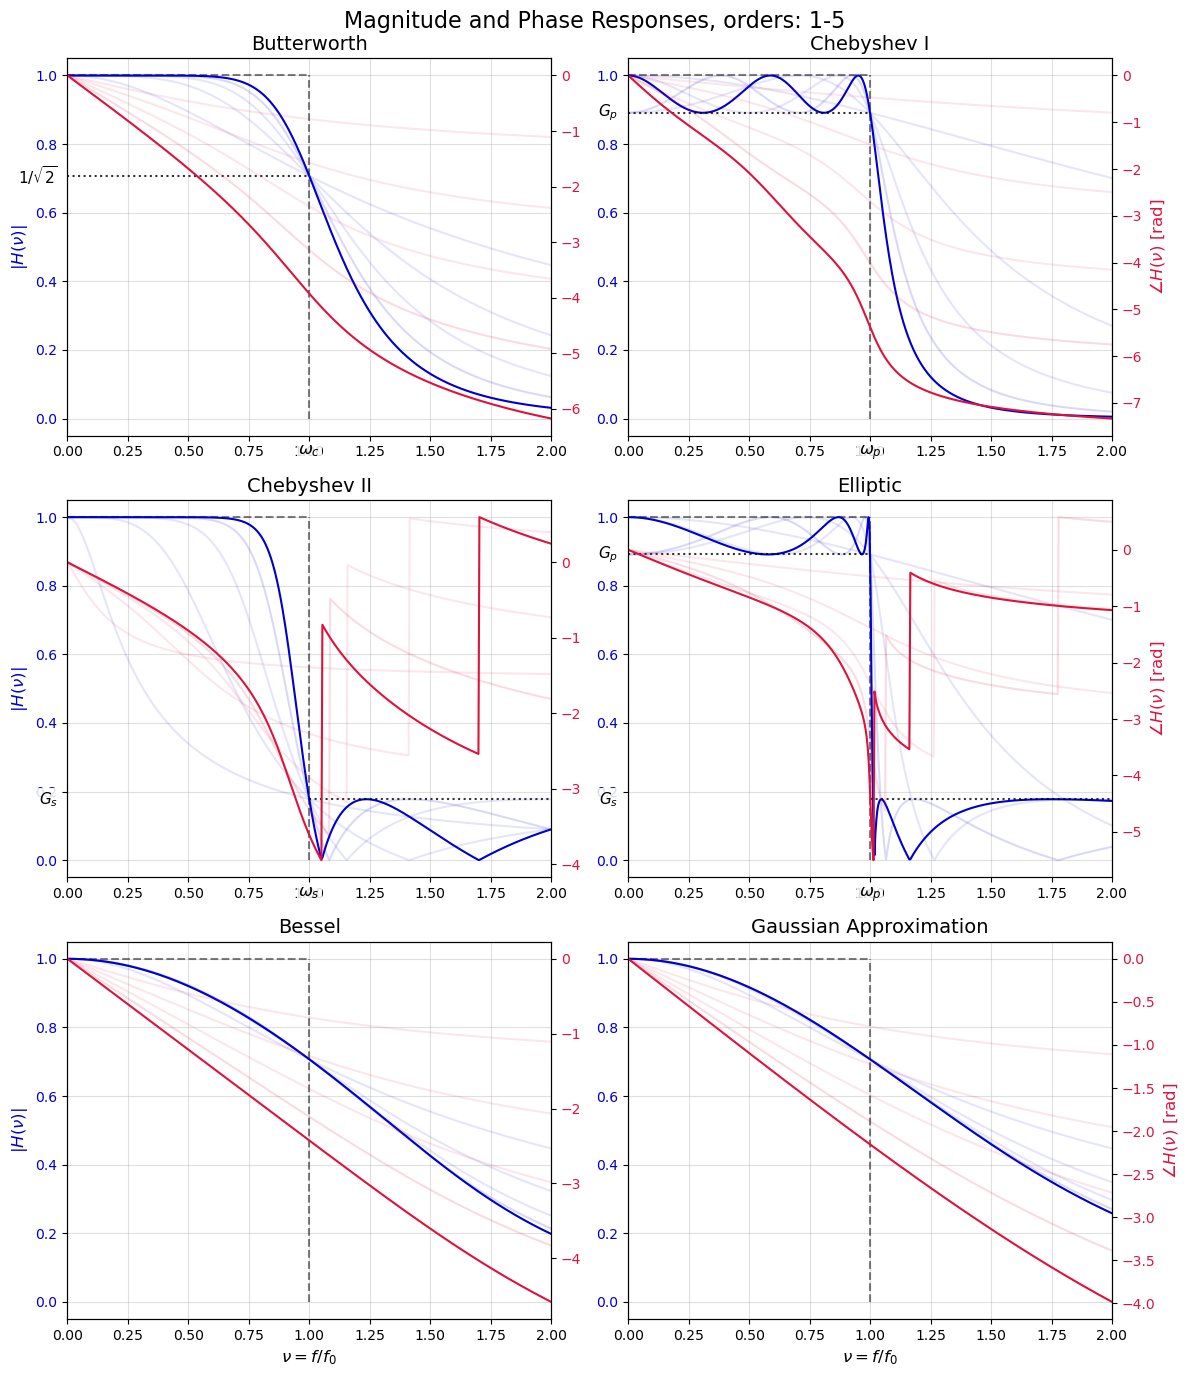

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Названия фильтров (на английском)
filters =['Butterworth', 'Chebyshev I', 'Chebyshev II', 
           'Elliptic', 'Bessel', 'Gaussian Approximation']

# Порядки фильтров
orders =[1, 2, 3, 4, 5]

# Массив частот
w = np.linspace(0, 2, 500)

# ================= ПАРАМЕТРЫ ФИЛЬТРОВ =================
rp = 1.0   # Макс. неравномерность в полосе пропускания (дБ)
rs = 15.0  # Мин. затухание в полосе подавления (дБ) - БЫЛО 40, СТАЛО 15!

# Перевод из дБ в линейную амплитуду (для графика)
Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_butter = 1 / np.sqrt(2) # Уровень 1/sqrt(2) или -3 дБ
# =======================================================

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    
    coeffs =[((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0:
            s_roots.append(s1)
        elif s2.real < 0:
            s_roots.append(s2)
            
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses, orders: 1-5', fontsize=16, y=0.98)

for i, title in enumerate(filters):
    ax1 = axes[i]             # Левая ось (АЧХ)
    ax2 = ax1.twinx()         # Правая ось (ФЧХ)
    
    ax1.set_title(title, fontsize=14)
    
    # Уголок, который трогать запрещено:
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1], [0, 1], color='black', linestyle='--', alpha=0.5)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:
            b, a = signal.butter(N, 1, analog=True)
        elif i == 1:
            b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2:
            # ИСПОЛЬЗУЕМ rs=15 вместо 40
            b, a = signal.cheby2(N, rs, 1, analog=True) 
        elif i == 3:
            # ИСПОЛЬЗУЕМ rp=1, rs=15
            b, a = signal.ellip(N, rp, rs, 1, analog=True) 
        elif i == 4:
            b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5:
            b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # === ДОБАВЛЕНИЕ ЛИНИЙ И БУКВЕННЫХ ПОДПИСЕЙ ===
    # Настройки для отрисовки дополнительных линий и текста
    line_kws = {'color': 'black', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8}
    bbox_props = dict(boxstyle="square,pad=0.1", facecolor="white", edgecolor="none", alpha=0.85)
    
    # transform=ax1.get_yaxis_transform() позволяет задавать X в координатах осей (0-1), а Y в данных графика
    text_y_kws = {'transform': ax1.get_yaxis_transform(), 'va': 'center', 'ha': 'right', 'fontsize': 11, 'bbox': bbox_props, 'clip_on': False}
    text_x_kws = {'transform': ax1.get_xaxis_transform(), 'va': 'top', 'ha': 'center', 'fontsize': 12, 'bbox': bbox_props, 'clip_on': False}

    if i == 0: # Butterworth
        ax1.plot([0, 1], [G_butter, G_butter], **line_kws)
        ax1.text(-0.02, G_butter, r'$1/\sqrt{2}$', **text_y_kws)
        ax1.text(1.0, -0.02, r'$\omega_c$', **text_x_kws)
        
    elif i == 1: # Chebyshev I
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        ax1.text(-0.02, Gp, r'$G_p$', **text_y_kws)
        ax1.text(1.0, -0.02, r'$\omega_p$', **text_x_kws)
        
    elif i == 2: # Chebyshev II
        ax1.plot([1, 2], [Gs, Gs], **line_kws)
        ax1.text(-0.02, Gs, r'$G_s$', **text_y_kws)
        ax1.text(1.0, -0.02, r'$\omega_s$', **text_x_kws)
        
    elif i == 3: # Elliptic
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        ax1.plot([1, 2], [Gs, Gs], **line_kws)
        ax1.text(-0.02, Gp, r'$G_p$', **text_y_kws)
        ax1.text(-0.02, Gs, r'$G_s$', **text_y_kws)
        ax1.text(1.0, -0.02, r'$\omega_p$', **text_x_kws)
    # ===============================================

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

fig.tight_layout()
plt.show()

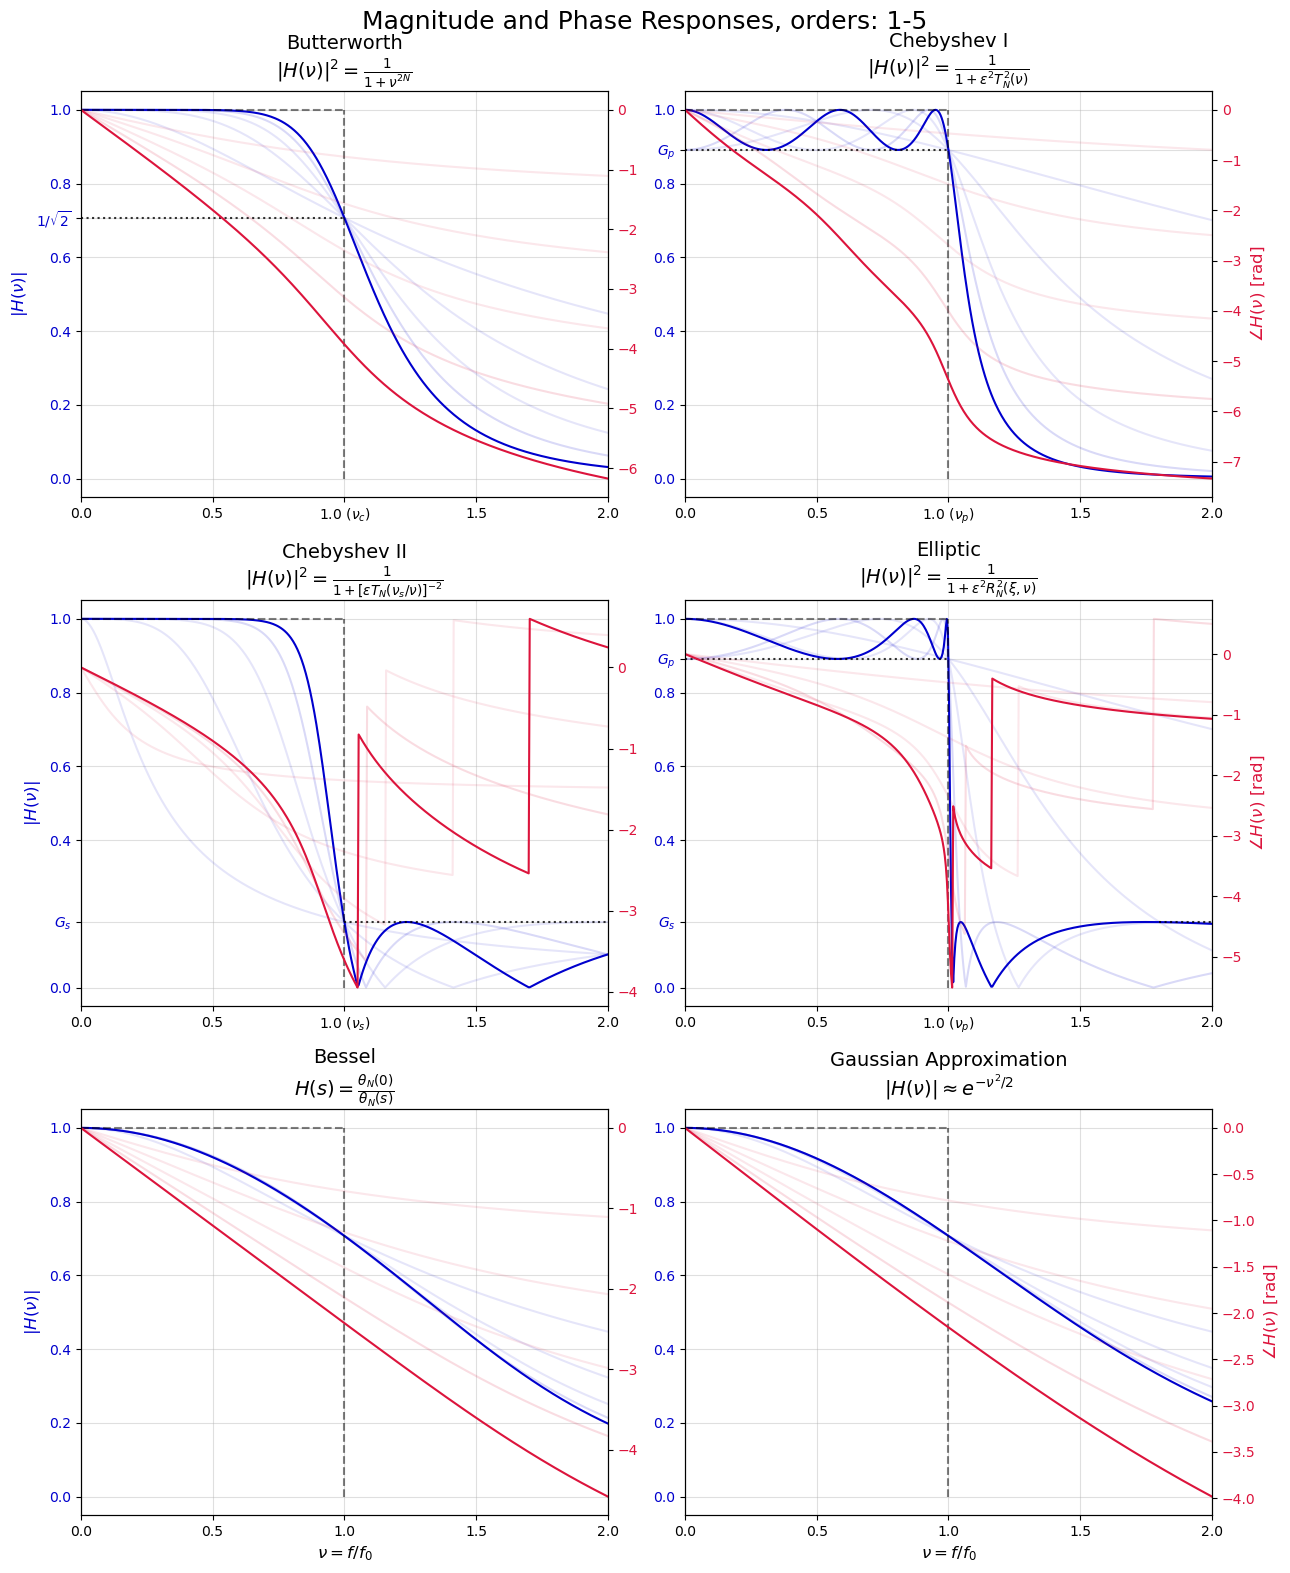

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Параметры фильтров
rp = 1.0   # Макс. неравномерность в полосе пропускания (дБ)
rs = 15.0  # Мин. затухание в полосе подавления (дБ)
orders = [1, 2, 3, 4, 5]
w = np.linspace(0, 2, 500)

# Перевод из дБ в линейную амплитуду (для графика)
Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_butter = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs =[((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Названия и формулы фильтров
filters_info =[
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 +[\epsilon T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 R_N^2(\xi, \nu)}$'),
    (4, 'Bessel', r'$H(s) = \frac{\theta_N(0)}{\theta_N(s)}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)| \approx e^{-\nu^2/2}$')
]

# Функция для "умной" установки Y-тиков без наслоений текста
def apply_custom_yticks(ax, custom_vals, custom_labels):
    std_y =[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [],[]
    for y in std_y:
        # Убираем стандартные цифры, если они слишком близко к нашим буквам
        if not any(abs(y - cy) < 0.08 for cy in custom_vals):
            final_y.append(y)
            final_yl.append(f"{y:.1f}")
    
    final_y.extend(custom_vals)
    final_yl.extend(custom_labels)
    
    # Сортируем тики, чтобы они шли по порядку
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

# Увеличили размер фигуры, чтобы вместить двухэтажные формулы
fig, axes = plt.subplots(3, 2, figsize=(13, 16))
axes = axes.flatten()
fig.suptitle('Magnitude and Phase Responses, orders: 1-5', fontsize=18, y=0.98)
plt.subplots_adjust(hspace=0.4)

for i, title, formula in filters_info:
    ax1 = axes[i]             
    ax2 = ax1.twinx()         
    
    # Заголовок + Формула
    ax1.set_title(f"{title}\n{formula}", fontsize=14, pad=10)
    
    all_mags =[] # Для сохранения расчетов
    
    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:   b, a = signal.butter(N, 1, analog=True)
        elif i == 1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i == 3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i == 4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5: b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        all_mags.append(mag)
        
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # --- УГОЛОК (трогать запрещено) ---
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1],[0, 1], color='black', linestyle='--', alpha=0.5)
    # ----------------------------------

    # --- ФИЗИЧЕСКИЕ ЛИНИИ И УМНЫЕ ОСИ ---
    line_kws = {'color': 'black', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8}
    x_label_1 = '1.0'
    
    if i == 0: # Butterworth
        ax1.plot([0, 1], [G_butter, G_butter], **line_kws)
        apply_custom_yticks(ax1, [G_butter],[r'$1/\sqrt{2}$'])
        x_label_1 = r'$1.0 \ (\nu_c)$'
        
    elif i == 1: # Chebyshev I
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        apply_custom_yticks(ax1, [Gp], [r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    elif i == 2: # Chebyshev II
        ax1.plot([1, 2], [Gs, Gs], **line_kws)
        apply_custom_yticks(ax1, [Gs], [r'$G_s$'])
        x_label_1 = r'$1.0 \ (\nu_s)$'
        
    elif i == 3: # Elliptic
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        
        # Динамический поиск начала полосы подавления G_s, чтобы линия не резала спад!
        valid_ws =[]
        for mag in all_mags:
            idx_gs = np.where(mag <= Gs * 1.01)[0]
            if len(idx_gs) > 0:
                valid_ws.append(w[idx_gs[0]])
                
        if valid_ws:
            max_w_stopband = max(valid_ws)
            # Рисуем линию только с того момента, где фильтры уже упали на дно
            ax1.plot([max_w_stopband, 2], [Gs, Gs], **line_kws)
            
        apply_custom_yticks(ax1, [Gs, Gp],[r'$G_s$', r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    else: # Bessel & Gaussian
        apply_custom_yticks(ax1,[],[])

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4, zorder=0)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # Назначение X-тиков с объединением "числа + буквы"
    ax1.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax1.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

# Мелкая подгонка для избежания наслоений
fig.tight_layout()
plt.show()

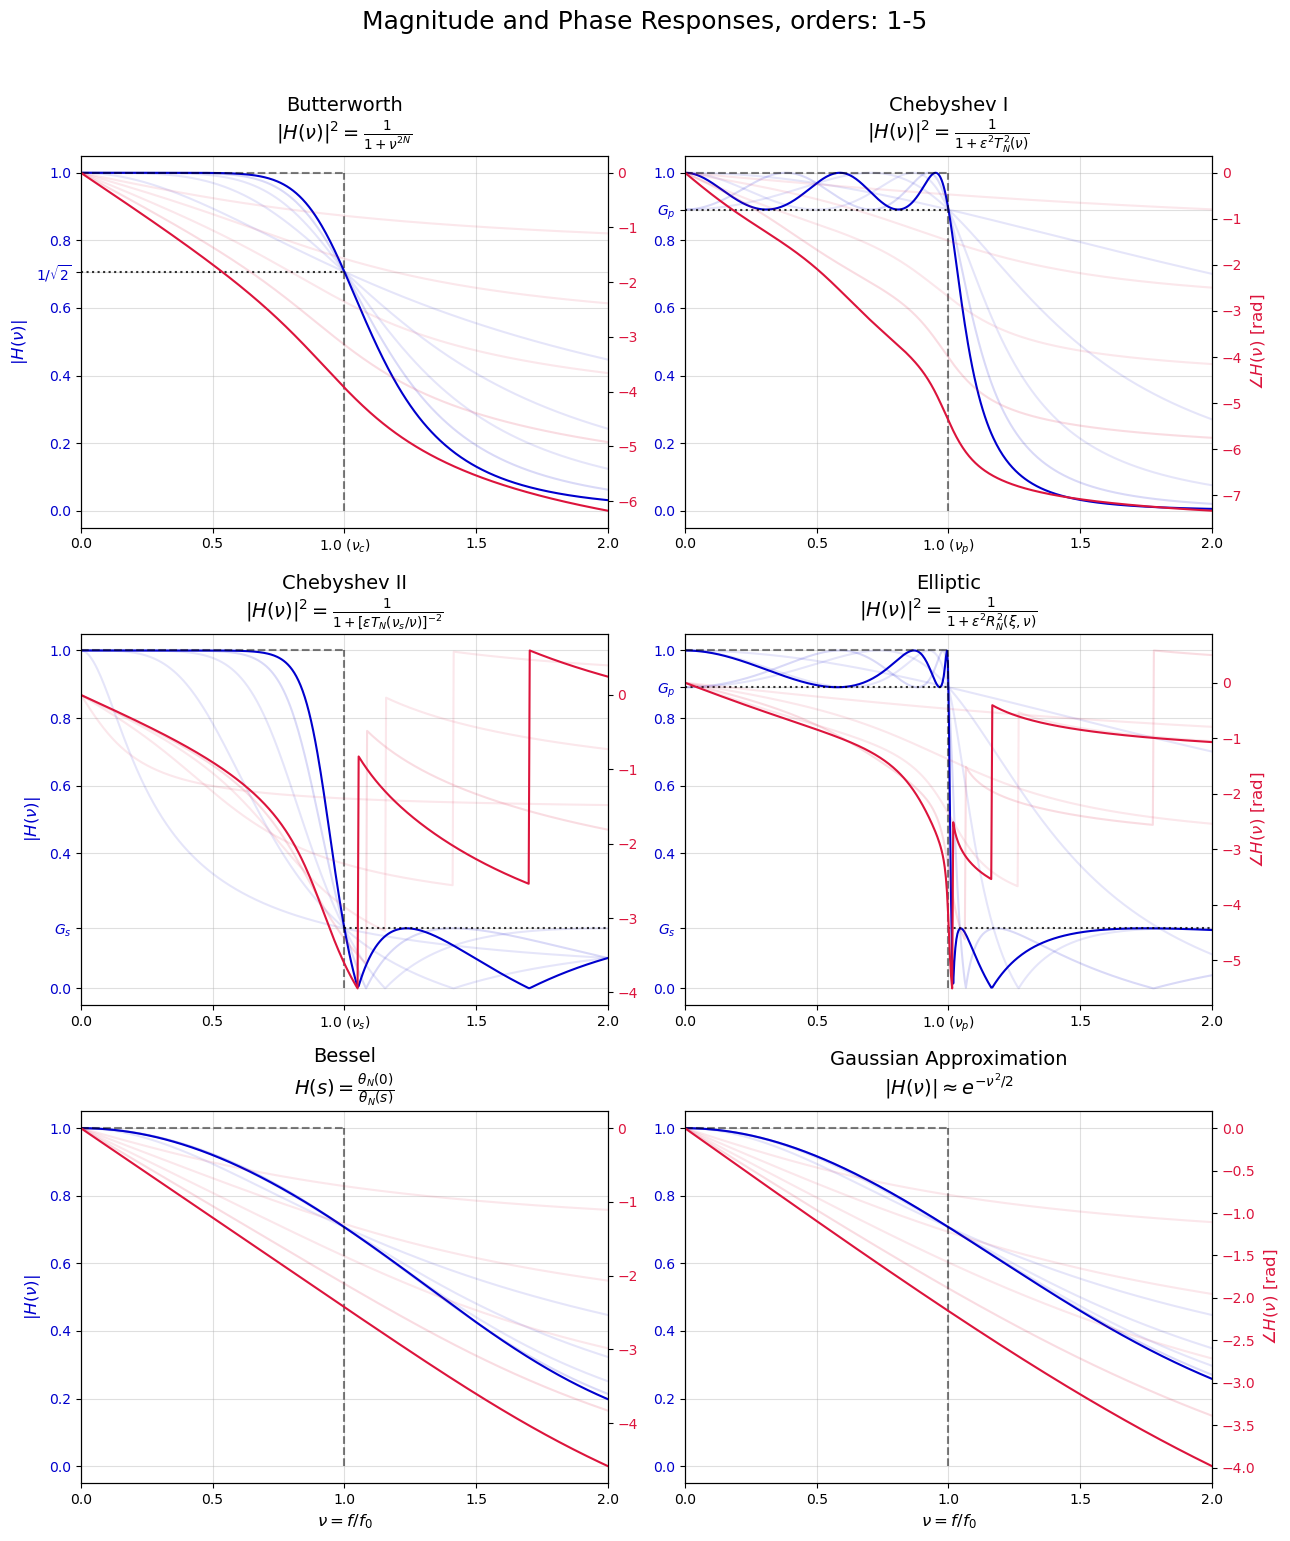

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Параметры фильтров
rp = 1.0   # Макс. неравномерность в полосе пропускания (дБ)
rs = 15.0  # Мин. затухание в полосе подавления (дБ)
orders =[1, 2, 3, 4, 5]
w = np.linspace(0, 2, 500)

# Перевод из дБ в линейную амплитуду
Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_butter = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs =[((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Названия и формулы фильтров
filters_info =[
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 + [\epsilon T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon^2 R_N^2(\xi, \nu)}$'),
    (4, 'Bessel', r'$H(s) = \frac{\theta_N(0)}{\theta_N(s)}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)| \approx e^{-\nu^2/2}$')
]

# Функция для установки тиков оси Y без текстовых наслоений
def apply_custom_yticks(ax, custom_vals, custom_labels):
    std_y =[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [],[]
    for y in std_y:
        if not any(abs(y - cy) < 0.08 for cy in custom_vals):
            final_y.append(y)
            final_yl.append(f"{y:.1f}")
    
    final_y.extend(custom_vals)
    final_yl.extend(custom_labels)
    
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

fig, axes = plt.subplots(3, 2, figsize=(13, 16))
axes = axes.flatten()

# Заголовок теперь без y-сдвига, мы настроим отступ через tight_layout
fig.suptitle('Magnitude and Phase Responses, orders: 1-5', fontsize=18)

for i, title, formula in filters_info:
    ax1 = axes[i]             
    ax2 = ax1.twinx()         
    
    ax1.set_title(f"{title}\n{formula}", fontsize=14, pad=12)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:   b, a = signal.butter(N, 1, analog=True)
        elif i == 1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i == 3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i == 4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5: b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # --- УГОЛОК (неприкосновенный) ---
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1],[0, 1], color='black', linestyle='--', alpha=0.5)
    # ---------------------------------

    # Линии уровней Gp, Gs
    line_kws = {'color': 'black', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8}
    x_label_1 = '1.0'
    
    if i == 0: # Butterworth
        ax1.plot([0, 1], [G_butter, G_butter], **line_kws)
        apply_custom_yticks(ax1, [G_butter],[r'$1/\sqrt{2}$'])
        x_label_1 = r'$1.0 \ (\nu_c)$'
        
    elif i == 1: # Chebyshev I
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        apply_custom_yticks(ax1, [Gp], [r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    elif i == 2: # Chebyshev II
        ax1.plot([1, 2],[Gs, Gs], **line_kws)
        apply_custom_yticks(ax1, [Gs],[r'$G_s$'])
        x_label_1 = r'$1.0 \ (\nu_s)$'
        
    elif i == 3: # Elliptic
        ax1.plot([0, 1],[Gp, Gp], **line_kws)
        # ВЕРНУЛИ ЛИНИЮ К УГОЛКУ
        ax1.plot([1, 2], [Gs, Gs], **line_kws) 
        
        apply_custom_yticks(ax1, [Gs, Gp],[r'$G_s$', r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    else: # Bessel & Gaussian
        apply_custom_yticks(ax1,[],[])

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4, zorder=0)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # X-тики
    ax1.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax1.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

# Исправляем отступы: rect=[left, bottom, right, top]
# Резервируем верхние 4% рисунка под главный заголовок
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

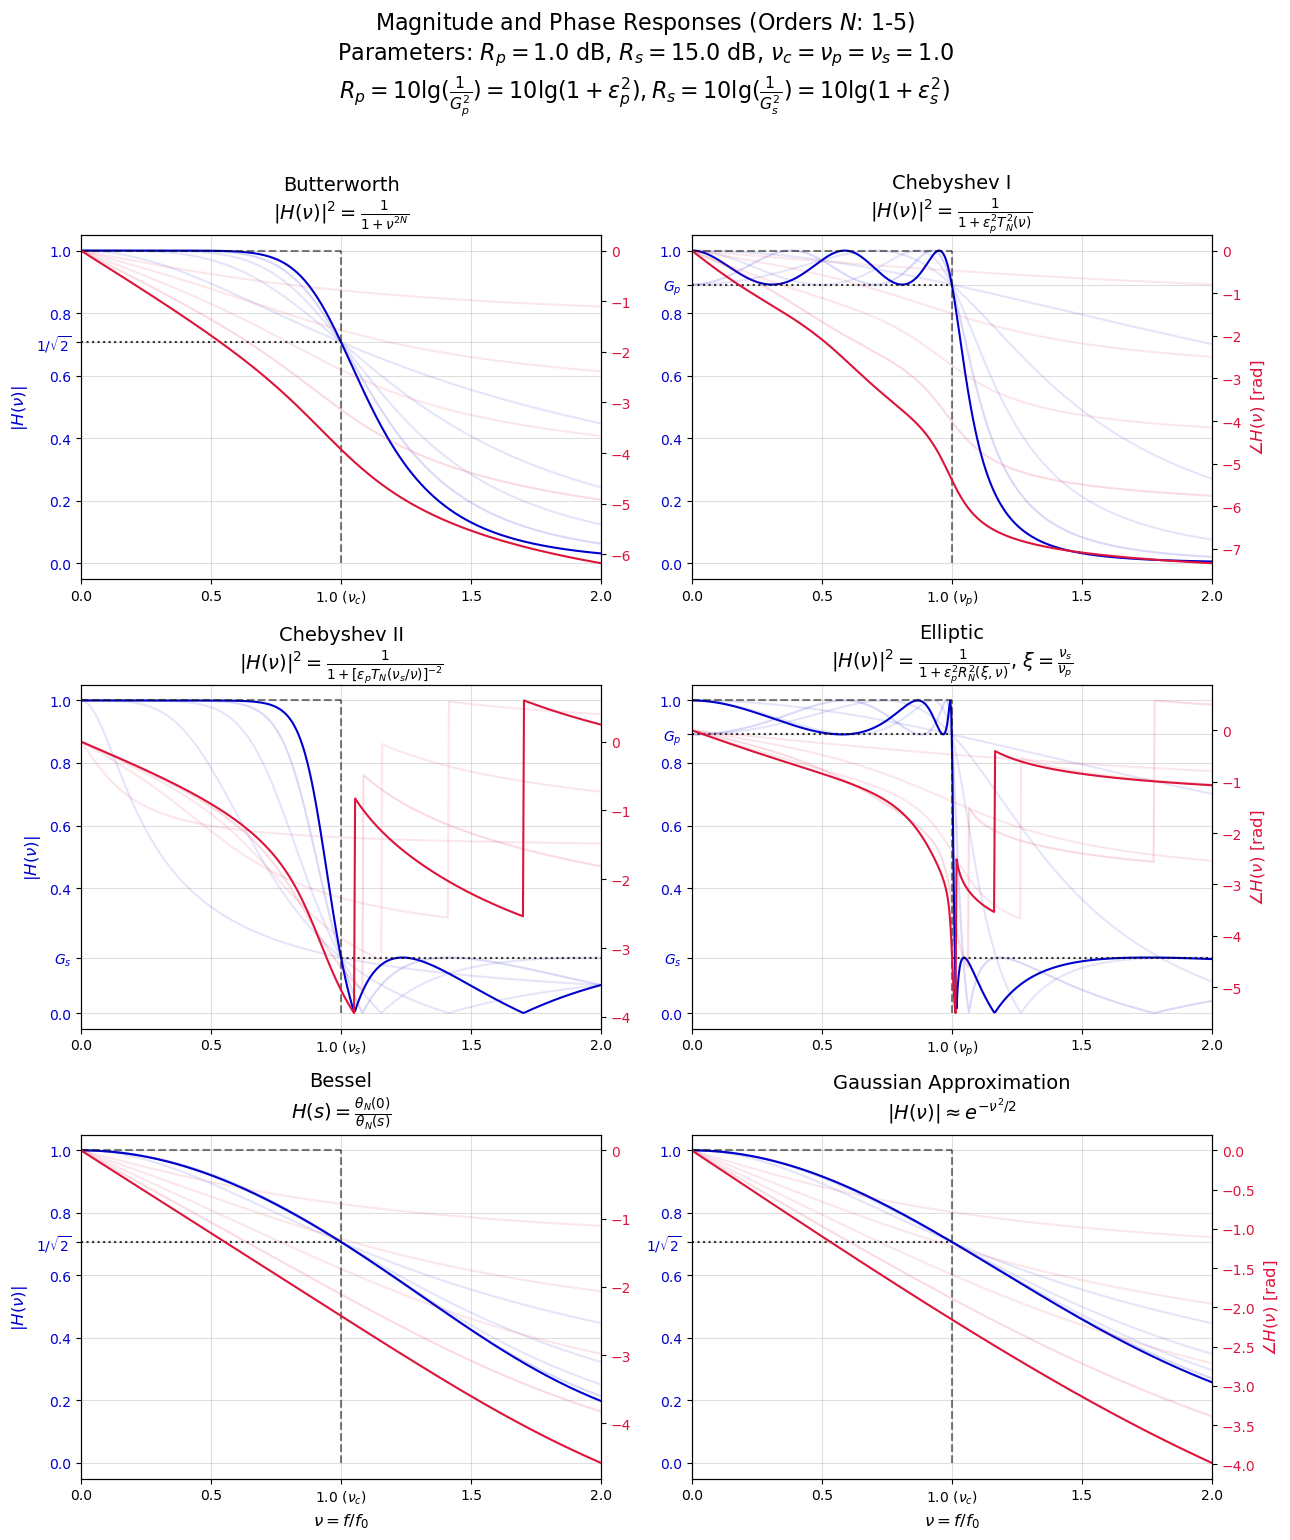

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Параметры фильтров
rp = 1.0   # Макс. неравномерность в полосе пропускания (дБ)
rs = 15.0  # Мин. затухание в полосе подавления (дБ)
orders =[1, 2, 3, 4, 5]
w = np.linspace(0, 2, 500)

# Перевод из дБ в линейную амплитуду
Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_butter = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs =[((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j)
        s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    num = [den[-1].real]
    return num, den.real

# Названия и формулы фильтров
filters_info =[
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon_p^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 +[\epsilon_p T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \epsilon_p^2 R_N^2(\xi, \nu)}$, $\xi = \frac{\nu_s}{\nu_p}$'),
    (4, 'Bessel', r'$H(s) = \frac{\theta_N(0)}{\theta_N(s)}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)| \approx e^{-\nu^2/2}$')
]

# Функция для установки тиков оси Y без текстовых наслоений
def apply_custom_yticks(ax, custom_vals, custom_labels):
    std_y =[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [],[]
    for y in std_y:
        if not any(abs(y - cy) < 0.08 for cy in custom_vals):
            final_y.append(y)
            final_yl.append(f"{y:.1f}")
    
    final_y.extend(custom_vals)
    final_yl.extend(custom_labels)
    
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])

# Цветовая схема
color_mag = 'mediumblue'
color_phase = 'crimson'

fig, axes = plt.subplots(3, 2, figsize=(13, 16))
axes = axes.flatten()

# Обновленный главный заголовок с параметрами
title_str = (
    r'Magnitude and Phase Responses (Orders $N$: 1-5)' + '\n' +
    fr'Parameters: $R_p = {rp}$ dB, $R_s = {rs}$ dB, $\nu_c = \nu_p = \nu_s = 1.0$' + '\n' +
    r'$R_p = 10\mathrm{lg}(\frac{1}{G_p^2}) = 10\mathrm{lg}(1 + \varepsilon_p^2), R_s = 10\mathrm{lg}(\frac{1}{G_s^2}) = 10\mathrm{lg}(1 + \varepsilon_s^2)$' + '\n'
)
fig.suptitle(title_str, fontsize=16)

for i, title, formula in filters_info:
    ax1 = axes[i]             
    ax2 = ax1.twinx()         
    
    ax1.set_title(f"{title}\n{formula}", fontsize=14, pad=12)
    
    for idx, N in enumerate(orders):
        alpha_val = 0.1 + 0.9 * (idx / (len(orders) - 1))**10
        
        if i == 0:   b, a = signal.butter(N, 1, analog=True)
        elif i == 1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i == 2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i == 3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i == 4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i == 5: b, a = get_gaussian_analog_filter(N)
            
        _, h = signal.freqs(b, a, w)
        mag = np.abs(h)
        phase = np.unwrap(np.angle(h))
        
        ax1.plot(w, mag, color=color_mag, alpha=alpha_val)
        ax2.plot(w, phase, color=color_phase, alpha=alpha_val)

    # --- УГОЛОК (неприкосновенный) ---
    ax1.plot([0, 1], [1, 1], color='black', linestyle='--', alpha=0.5)
    ax1.plot([1, 1],[0, 1], color='black', linestyle='--', alpha=0.5)
    # ---------------------------------

    # Линии уровней Gp, Gs, G_butter
    line_kws = {'color': 'black', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8}
    x_label_1 = '1.0'
    
    if i == 0: # Butterworth
        ax1.plot([0, 1], [G_butter, G_butter], **line_kws)
        apply_custom_yticks(ax1, [G_butter],[r'$1/\sqrt{2}$'])
        x_label_1 = r'$1.0 \ (\nu_c)$'
        
    elif i == 1: # Chebyshev I
        ax1.plot([0, 1], [Gp, Gp], **line_kws)
        apply_custom_yticks(ax1, [Gp],[r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    elif i == 2: # Chebyshev II
        ax1.plot([1, 2],[Gs, Gs], **line_kws)
        apply_custom_yticks(ax1,[Gs],[r'$G_s$'])
        x_label_1 = r'$1.0 \ (\nu_s)$'
        
    elif i == 3: # Elliptic
        ax1.plot([0, 1],[Gp, Gp], **line_kws)
        ax1.plot([1, 2], [Gs, Gs], **line_kws) 
        
        apply_custom_yticks(ax1, [Gs, Gp],[r'$G_s$', r'$G_p$'])
        x_label_1 = r'$1.0 \ (\nu_p)$'
        
    elif i in [4, 5]: # Bessel & Gaussian
        ax1.plot([0, 1], [G_butter, G_butter], **line_kws)
        apply_custom_yticks(ax1, [G_butter],[r'$1/\sqrt{2}$'])
        x_label_1 = r'$1.0 \ (\nu_c)$'

    # Оформление левой оси (АЧХ)
    ax1.grid(True, linestyle='-', alpha=0.4, zorder=0)
    ax1.set_xlim(0, 2)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    
    # X-тики
    ax1.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax1.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])
    
    # Оформление правой оси (ФЧХ)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    
    if i >= 4:
        ax1.set_xlabel(r'$\nu = f/f_0$', fontsize=12)
        
    if i % 2 == 0:
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag, fontsize=12)
    if i % 2 == 1:
        ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase, fontsize=12)

# Исправляем отступы: rect=[left, bottom, right, top]
# Резервируем верхние 6% (вместо 4%) под двухстрочный главный заголовок
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

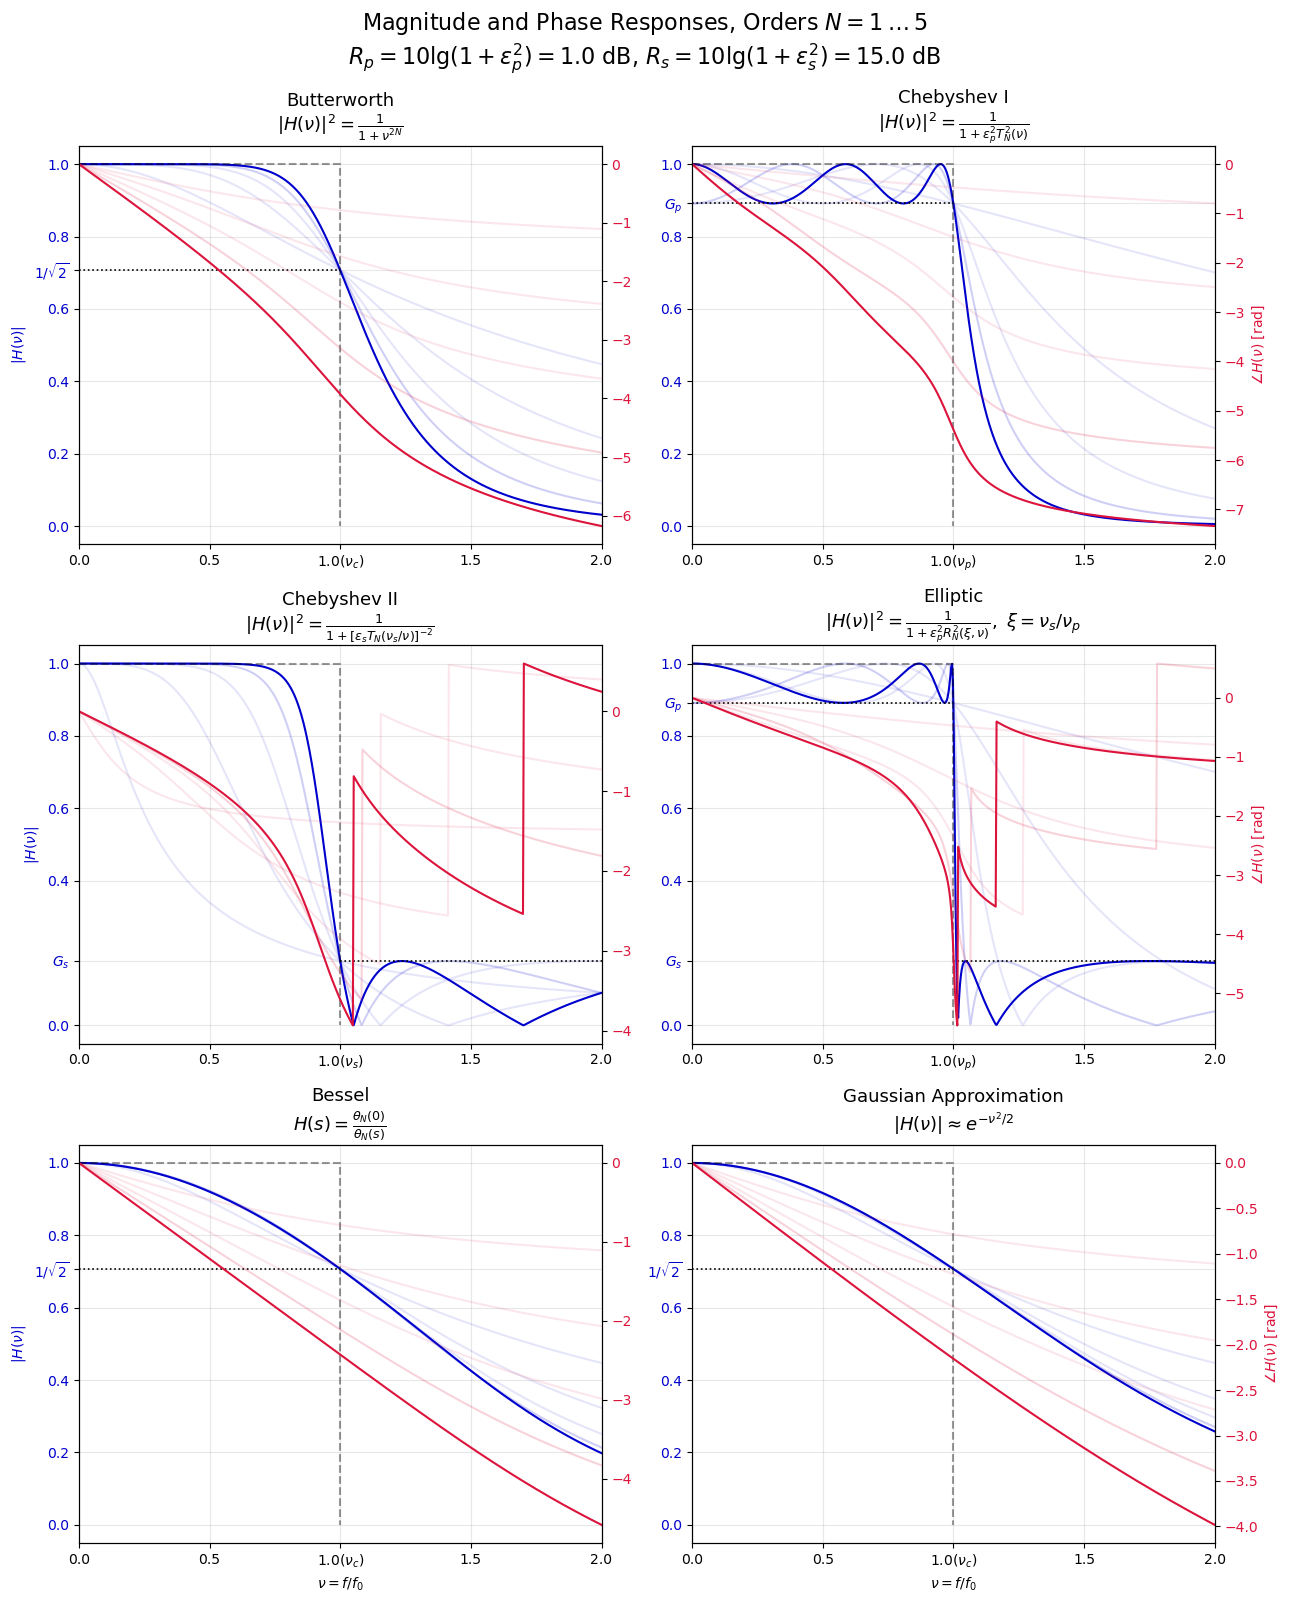

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

# Настройка стилей
plt.style.use('default')

# Параметры фильтров
rp = 1.0   # Passband ripple (dB) -> определяет epsilon_p
rs = 15.0  # Stopband attenuation (dB) -> определяет epsilon_s
orders = [1, 2, 3, 4, 5]
w = np.linspace(0, 2, 600)

# Линейные уровни
Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_3db = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots = []
    for x in x_roots:
        s1 = np.sqrt(x + 0j); s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    return [den[-1].real], den.real

# Описания фильтров
filters_info = [
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 + [\varepsilon_s T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 R_N^2(\xi, \nu)}, \ \xi = \nu_s/\nu_p$'),
    (4, 'Bessel', r'$H(s) = \frac{\theta_N(0)}{\theta_N(s)}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)| \approx e^{-\nu^2/2}$')
]

def apply_custom_ticks(ax, y_vals, y_labels, x_label_1):
    # Y-ось
    std_y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [], []
    for y in std_y:
        if not any(abs(y - cv) < 0.07 for cv in y_vals):
            final_y.append(y); final_yl.append(f"{y:.1f}")
    final_y.extend(y_vals); final_yl.extend(y_labels)
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])
    
    # X-ось
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])

color_mag, color_phase = 'mediumblue', 'crimson'
fig, axes = plt.subplots(3, 2, figsize=(13, 17))
axes = axes.flatten()

# Общий заголовок с расшифровкой параметров
title_main = r'Magnitude and Phase Responses, Orders $N=1 \dots 5$'
params_text = (r'$R_p = 10\lg(1+\varepsilon_p^2) = %.1f$ dB, ' % rp + 
               r'$R_s = 10\lg(1+\varepsilon_s^2) = %.1f$ dB' % rs)
fig.suptitle(title_main + '\n' + params_text, fontsize=16, y=0.97)

for i, title, formula in filters_info:
    ax1, ax2 = axes[i], axes[i].twinx()
    ax1.set_title(f"{title}\n{formula}", fontsize=13, pad=10)
    
    for idx, N in enumerate(orders):
        alpha = 0.1 + 0.9 * (idx / 4)**8
        if i==0: b, a = signal.butter(N, 1, analog=True)
        elif i==1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i==2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i==3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i==4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i==5: b, a = get_gaussian_analog_filter(N)
        
        _, h = signal.freqs(b, a, w)
        ax1.plot(w, np.abs(h), color=color_mag, alpha=alpha)
        ax2.plot(w, np.unwrap(np.angle(h)), color=color_phase, alpha=alpha)

    # Уголок (Запрещено трогать)
    ax1.plot([0, 1, 1], [1, 1, 0], color='black', linestyle='--', alpha=0.4)

    # Линии и тики
    l_style = {'color': 'black', 'linestyle': ':', 'linewidth': 1.2}
    if i == 0: # Butterworth
        ax1.plot([0, 1], [G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1, [G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')
    elif i == 1: # Cheby I
        ax1.plot([0, 1], [Gp, Gp], **l_style)
        apply_custom_ticks(ax1, [Gp], [r'$G_p$'], r'$1.0(\nu_p)$')
    elif i == 2: # Cheby II
        ax1.plot([1, 2], [Gs, Gs], **l_style)
        apply_custom_ticks(ax1, [Gs], [r'$G_s$'], r'$1.0(\nu_s)$')
    elif i == 3: # Elliptic
        ax1.plot([0, 1], [Gp, Gp], **l_style)
        ax1.plot([1, 2], [Gs, Gs], **l_style)
        apply_custom_ticks(ax1, [Gp, Gs], [r'$G_p$', r'$G_s$'], r'$1.0(\nu_p)$')
    elif i in [4, 5]: # Bessel / Gauss
        ax1.plot([0, 1], [G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1, [G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')

    ax1.grid(True, alpha=0.3); ax1.set_xlim(0, 2); ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    if i >= 4: ax1.set_xlabel(r'$\nu = f/f_0$')
    if i % 2 == 0: ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag)
    else: ax2.set_ylabel(r'$\angle H(\nu)$ [rad]', color=color_phase)

fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

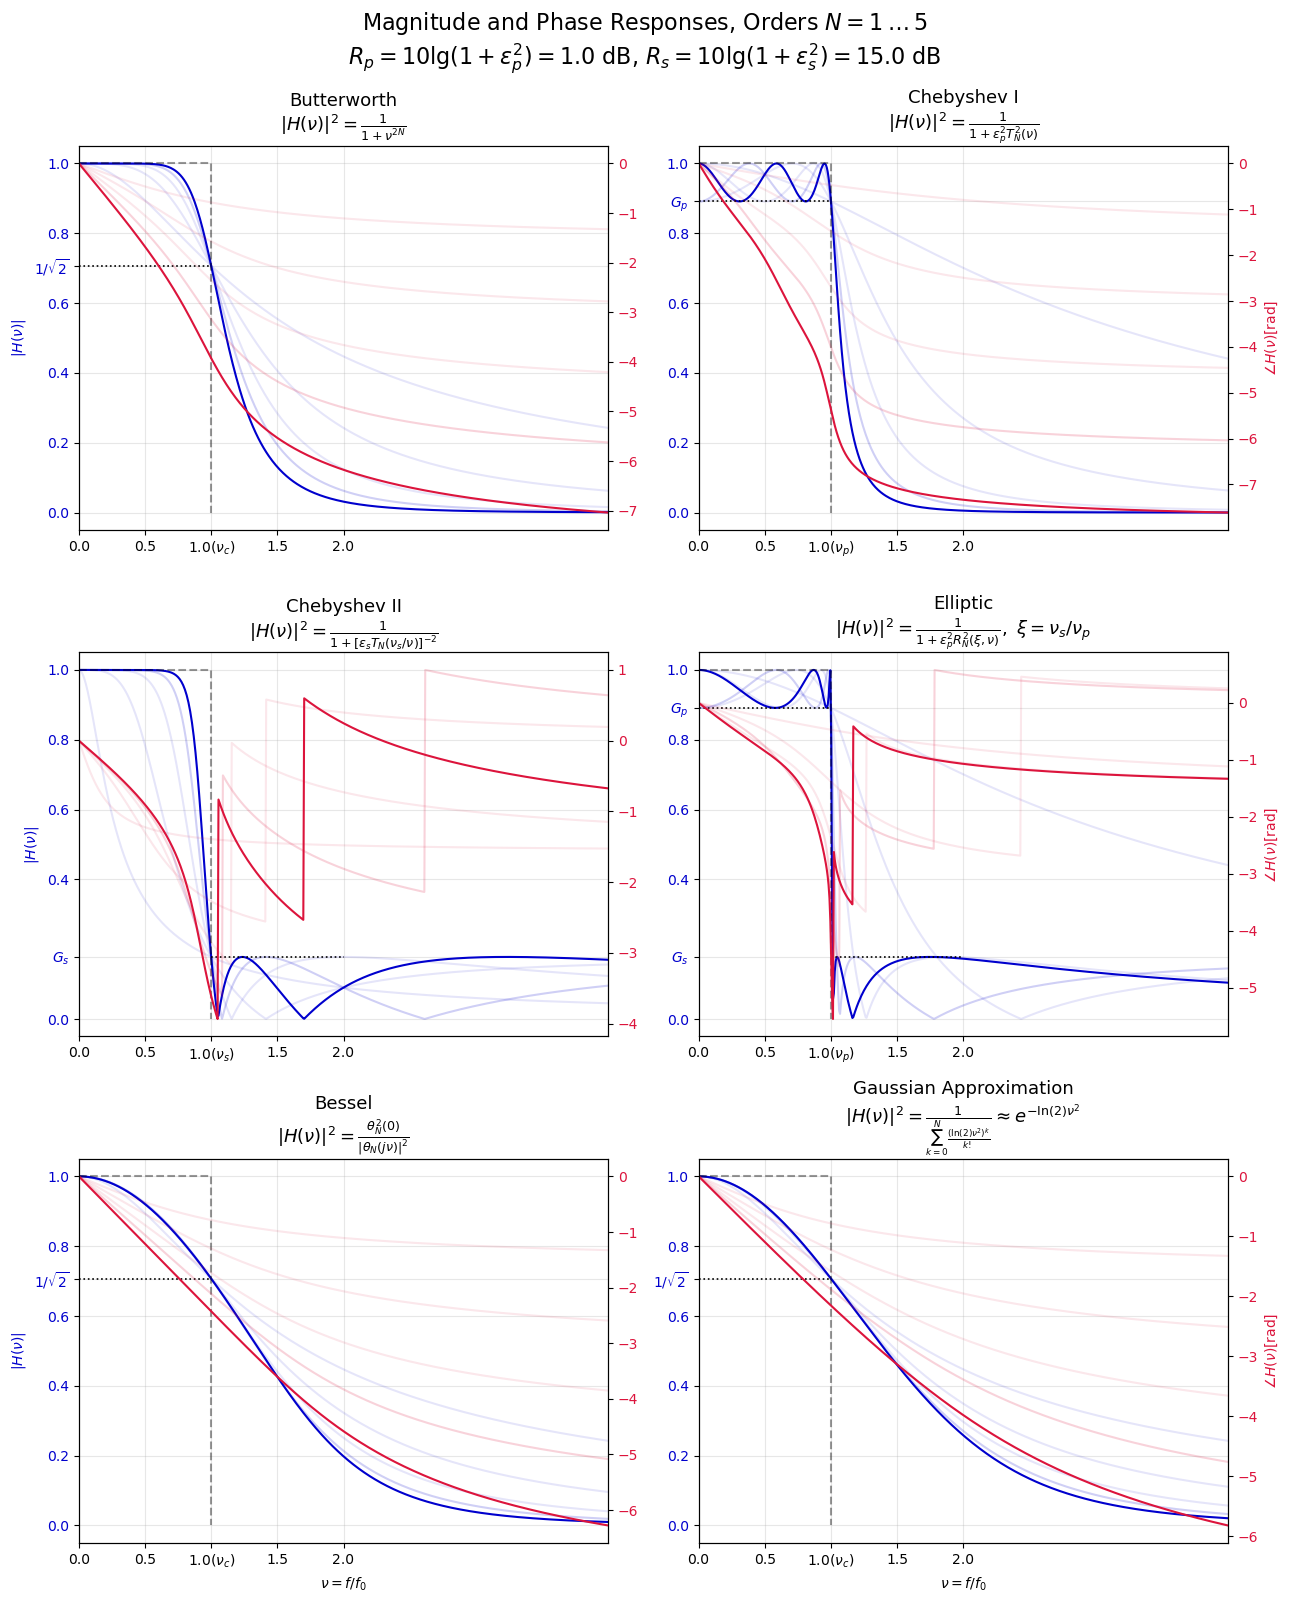

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

plt.style.use('default')

x_max = 4

rp = 1.0
rs = 15.0
orders = [1, 2, 3, 4, 5]
w = np.linspace(0, x_max, 600)

Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_3db = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs = [((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j); s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    return [den[-1].real], den.real

filters_info =[
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 +[\varepsilon_s T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 R_N^2(\xi, \nu)}, \ \xi = \nu_s/\nu_p$'),
    (4, 'Bessel', r'$|H(\nu)|^2 = \frac{\theta_N^2(0)}{|\theta_N(j\nu)|^2}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)|^2 = \frac{1}{\sum_{k=0}^N \frac{(\ln(2)\nu^2)^k}{k!}} \approx e^{-\ln(2)\nu^2}$')
]

def apply_custom_ticks(ax, y_vals, y_labels, x_label_1):
    
    std_y =[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [],[]
    for y in std_y:
        if not any(abs(y - cv) < 0.07 for cv in y_vals):
            final_y.append(y); final_yl.append(f"{y:.1f}")
    final_y.extend(y_vals); final_yl.extend(y_labels)
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])
    
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])

color_mag, color_phase = 'mediumblue', 'crimson'
fig, axes = plt.subplots(3, 2, figsize=(13, 17))
axes = axes.flatten()

title_main = r'Magnitude and Phase Responses, Orders $N=1 \dots 5$'
params_text = (r'$R_p = 10\lg(1+\varepsilon_p^2) = %.1f$ dB, ' % rp + 
               r'$R_s = 10\lg(1+\varepsilon_s^2) = %.1f$ dB' % rs)
fig.suptitle(title_main + '\n' + params_text, fontsize=16, y=0.97)

for i, title, formula in filters_info:
    ax1, ax2 = axes[i], axes[i].twinx()
    ax1.set_title(f"{title}\n{formula}", fontsize=13, pad=10)
    
    for idx, N in enumerate(orders):
        alpha = 0.1 + 0.9 * (idx / 4)**8
        if i==0: b, a = signal.butter(N, 1, analog=True)
        elif i==1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i==2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i==3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i==4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i==5: b, a = get_gaussian_analog_filter(N)
        
        _, h = signal.freqs(b, a, w)
        ax1.plot(w, np.abs(h), color=color_mag, alpha=alpha)
        ax2.plot(w, np.unwrap(np.angle(h)), color=color_phase, alpha=alpha)

    ax1.plot([0, 1, 1], [1, 1, 0], color='black', linestyle='--', alpha=0.4)

    l_style = {'color': 'black', 'linestyle': ':', 'linewidth': 1.2}
    if i == 0: # Butterworth
        ax1.plot([0, 1],[G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1,[G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')
    elif i == 1: # Cheby I
        ax1.plot([0, 1], [Gp, Gp], **l_style)
        apply_custom_ticks(ax1,[Gp], [r'$G_p$'], r'$1.0(\nu_p)$')
    elif i == 2: # Cheby II
        ax1.plot([1, 2],[Gs, Gs], **l_style)
        apply_custom_ticks(ax1, [Gs],[r'$G_s$'], r'$1.0(\nu_s)$')
    elif i == 3: # Elliptic
        ax1.plot([0, 1], [Gp, Gp], **l_style)
        ax1.plot([1, 2], [Gs, Gs], **l_style)
        apply_custom_ticks(ax1, [Gp, Gs],[r'$G_p$', r'$G_s$'], r'$1.0(\nu_p)$')
    elif i in [4, 5]: # Bessel / Gauss
        ax1.plot([0, 1],[G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1, [G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')

    ax1.grid(True, alpha=0.3); ax1.set_xlim(0, x_max); ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    if i >= 4: ax1.set_xlabel(r'$\nu = f/f_0$')
    if i % 2 == 0: ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag)
    else: ax2.set_ylabel(r'$\angle H(\nu)$[rad]', color=color_phase)

fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("filters_linscale_phases.pdf", format='pdf', bbox_inches='tight')
plt.savefig("filters_linscale_phases.png", format='png', bbox_inches='tight')

plt.show()

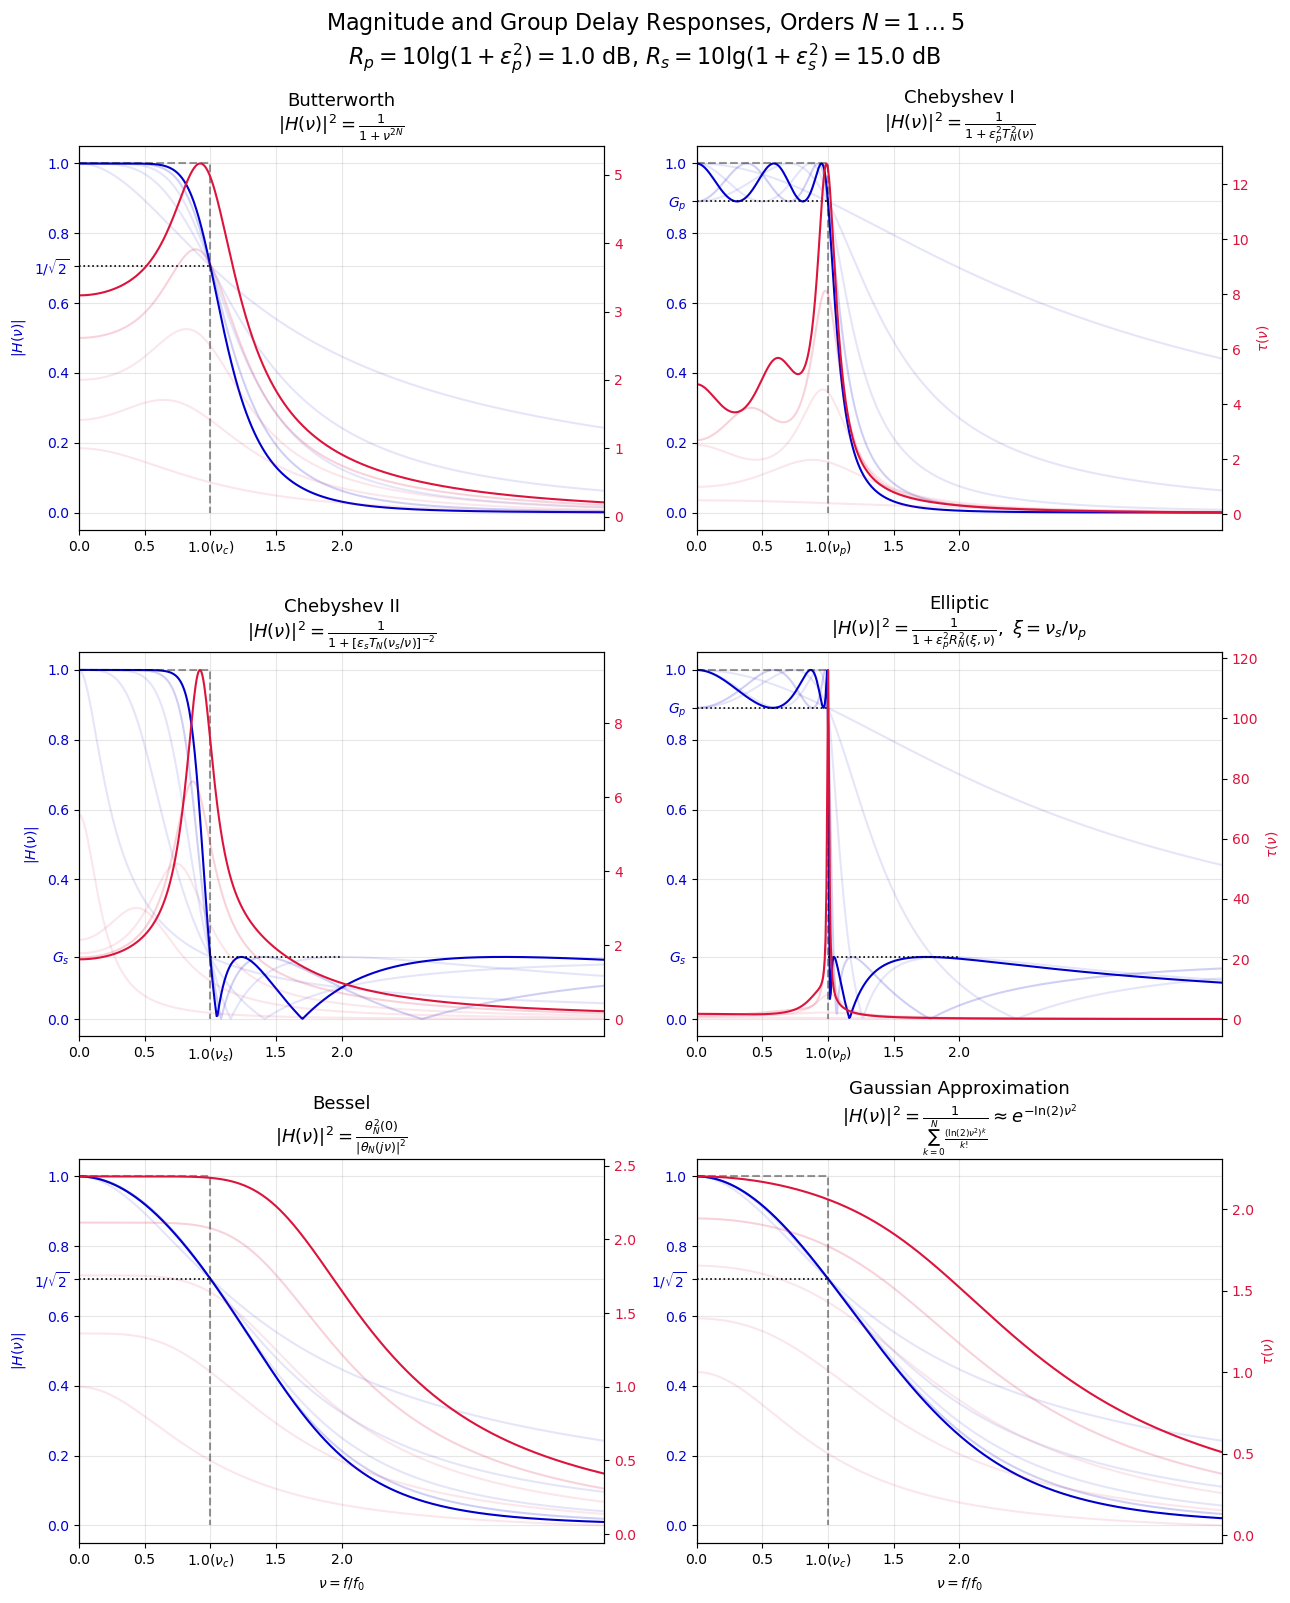

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root_scalar
import math

plt.style.use('default')

x_max = 4

rp = 1.0
rs = 15.0 
orders = [1, 2, 3, 4, 5]
w = np.linspace(0, x_max, 600)

Gp = 10**(-rp / 20)
Gs = 10**(-rs / 20)
G_3db = 1 / np.sqrt(2)

def get_gaussian_analog_filter(N):
    def obj(a):
        return sum((a**k) / math.factorial(k) for k in range(N+1)) - 2.0
    res = root_scalar(obj, bracket=[0.0001, 10])
    a = res.root
    coeffs =[((-a)**k) / math.factorial(k) for k in range(N+1)]
    coeffs.reverse()
    x_roots = np.roots(coeffs)
    s_roots =[]
    for x in x_roots:
        s1 = np.sqrt(x + 0j); s2 = -np.sqrt(x + 0j)
        if s1.real < 0: s_roots.append(s1)
        elif s2.real < 0: s_roots.append(s2)
    den = np.poly(s_roots)
    return [den[-1].real], den.real

filters_info =[
    (0, 'Butterworth', r'$|H(\nu)|^2 = \frac{1}{1 + \nu^{2N}}$'),
    (1, 'Chebyshev I', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 T_N^2(\nu)}$'),
    (2, 'Chebyshev II', r'$|H(\nu)|^2 = \frac{1}{1 +[\varepsilon_s T_N(\nu_s/\nu)]^{-2}}$'),
    (3, 'Elliptic', r'$|H(\nu)|^2 = \frac{1}{1 + \varepsilon_p^2 R_N^2(\xi, \nu)}, \ \xi = \nu_s/\nu_p$'),
    (4, 'Bessel', r'$|H(\nu)|^2 = \frac{\theta_N^2(0)}{|\theta_N(j\nu)|^2}$'),
    (5, 'Gaussian Approximation', r'$|H(\nu)|^2 = \frac{1}{\sum_{k=0}^N \frac{(\ln(2)\nu^2)^k}{k!}} \approx e^{-\ln(2)\nu^2}$')
]

def apply_custom_ticks(ax, y_vals, y_labels, x_label_1):
    std_y =[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    final_y, final_yl = [],[]
    for y in std_y:
        if not any(abs(y - cv) < 0.07 for cv in y_vals):
            final_y.append(y); final_yl.append(f"{y:.1f}")
    final_y.extend(y_vals); final_yl.extend(y_labels)
    sy = sorted(zip(final_y, final_yl), key=lambda p: p[0])
    ax.set_yticks([p[0] for p in sy])
    ax.set_yticklabels([p[1] for p in sy])
    
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.set_xticklabels(['0.0', '0.5', x_label_1, '1.5', '2.0'])

color_mag, color_gd = 'mediumblue', 'crimson'
fig, axes = plt.subplots(3, 2, figsize=(13, 17))
axes = axes.flatten()

title_main = r'Magnitude and Group Delay Responses, Orders $N=1 \dots 5$'
params_text = (r'$R_p = 10\lg(1+\varepsilon_p^2) = %.1f$ dB, ' % rp + 
               r'$R_s = 10\lg(1+\varepsilon_s^2) = %.1f$ dB' % rs)
fig.suptitle(title_main + '\n' + params_text, fontsize=16, y=0.97)

for i, title, formula in filters_info:
    ax1, ax2 = axes[i], axes[i].twinx()
    ax1.set_title(f"{title}\n{formula}", fontsize=13, pad=10)
    
    for idx, N in enumerate(orders):
        alpha = 0.1 + 0.9 * (idx / 4)**8
        if i==0: b, a = signal.butter(N, 1, analog=True)
        elif i==1: b, a = signal.cheby1(N, rp, 1, analog=True)
        elif i==2: b, a = signal.cheby2(N, rs, 1, analog=True)
        elif i==3: b, a = signal.ellip(N, rp, rs, 1, analog=True)
        elif i==4: b, a = signal.bessel(N, 1, analog=True, norm='mag')
        elif i==5: b, a = get_gaussian_analog_filter(N)
        
        _, h = signal.freqs(b, a, w)
        ax1.plot(w, np.abs(h), color=color_mag, alpha=alpha)
        
        s = 1j * w
        a_der = np.polyder(a)
        gd = np.real(np.polyval(a_der, s) / np.polyval(a, s))
        
        ax2.plot(w, gd, color=color_gd, alpha=alpha)

    ax1.plot([0, 1, 1], [1, 1, 0], color='black', linestyle='--', alpha=0.4)

    l_style = {'color': 'black', 'linestyle': ':', 'linewidth': 1.2}
    if i == 0:
        ax1.plot([0, 1],[G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1,[G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')
    elif i == 1:
        ax1.plot([0, 1], [Gp, Gp], **l_style)
        apply_custom_ticks(ax1,[Gp],[r'$G_p$'], r'$1.0(\nu_p)$')
    elif i == 2:
        ax1.plot([1, 2],[Gs, Gs], **l_style)
        apply_custom_ticks(ax1, [Gs],[r'$G_s$'], r'$1.0(\nu_s)$')
    elif i == 3:
        ax1.plot([0, 1],[Gp, Gp], **l_style)
        ax1.plot([1, 2],[Gs, Gs], **l_style)
        apply_custom_ticks(ax1,[Gp, Gs],[r'$G_p$', r'$G_s$'], r'$1.0(\nu_p)$')
    elif i in [4, 5]:
        ax1.plot([0, 1],[G_3db, G_3db], **l_style)
        apply_custom_ticks(ax1, [G_3db], [r'$1/\sqrt{2}$'], r'$1.0(\nu_c)$')

    ax1.grid(True, alpha=0.3); ax1.set_xlim(0, x_max); ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    ax2.tick_params(axis='y', labelcolor=color_gd)
    
    if i >= 4: ax1.set_xlabel(r'$\nu = f/f_0$')
    
    if i % 2 == 0: 
        ax1.set_ylabel(r'$|H(\nu)|$', color=color_mag)
    else: 
        ax2.set_ylabel(r'$\tau(\nu)$', color=color_gd)


fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("filters_linscale_tau.pdf", format='pdf', bbox_inches='tight')
plt.savefig("filters_linscale_tau.png", format='png', bbox_inches='tight')

plt.show()